<h1 style='color: #9b59b6; font-weight: bold;'>Анализ рынка строительной отрасли (малых и средних предприятий) в категории 41.20 "Строительство жилых и нежилых зданий" с 2021 по 2025 годы на основе данных открытых источников</h1>

**Задачи:**  
1. Собрать датасет на основе реестра всех предпренимателей из ФНС (юридические лица, средние и малые предприятия, 41.20 строительство жилых и нежилых зданий), парсинга данных с сайта https://bo.nalog.ru/      
2. Проанализировать рынок этой отрасли
3. Посчитать метрику EBITA всех компаний по годам
4. Построить график (x - процент роста чистой прибыли компании относительно N-летней давности, у - количество компаний с таким процентом)
5. Показать на карте топ500 компаний по выручке на карту по месту регистрации
6. Сформулировать выводы относительно прибыльности строительной отрасли

<h2 style='color: #9b59b6; font-weight: bold;'>Подготовка данных для анализа</h2>

In [ ]:
import pandas as pd
reestr = pd.read_excel('Реестр.xlsx')

In [5]:
#проверяем, что включает в себя датасет
reestr.head(10)

,Единый реестр субъектов малого и среднего предпринимательства по состоянию на 15.04.2024,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологично...",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за пред...
2,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
4,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
5,4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1
6,5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
7,6,"""БЕРЕГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1035010950633,5056003490,41.20 Строительство жилых и нежилых зданий,50 - Московская область,NaN,г Люберцы,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,2
8,7,"""БРИГ-С"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1022501801343,2537042746,41.20 Строительство жилых и нежилых зданий,25 - Приморский край,NaN,г Владивосток,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1
9,8,"""ВИВО"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800022842,7801201350,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.05.2020,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [1313]:
#делаем копию и в дальнейшем работаем с ней
#выделяем нужную строку в качестве заголовка
r = reestr.copy()
r.columns = r.iloc[1]
r = r.iloc[2:].reset_index(drop=True)
r.head(2)

1,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
1,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [1314]:
#изучаем размер датасета
r.shape

(603520, 23)

In [1315]:
#изучаем какие типы данных в датасете
r.dtypes

1
№ п/п                                                                       object
Наименование / ФИО                                                             str
Тип субъекта                                                                   str
Категория                                                                      str
ОГРН                                                                           str
ИНН                                                                            str
Основной вид деятельности                                                      str
Регион                                                                         str
Район                                                                          str
Город                                                                          str
Населенный пункт                                                               str
Вновь созданный                                                                str
Да

In [1316]:
#Приводим даты к типу данных datetime, среднесписочное число к float
r = r.astype({'Дата включения в реестр': 'datetime64[ns]', 
              'Дата исключения из реестра': 'datetime64[ns]', 
              'Среднесписочная численность работников за предшествующий календарный год': 'float'})
r.dtypes

1
№ п/п                                                                               object
Наименование / ФИО                                                                     str
Тип субъекта                                                                           str
Категория                                                                              str
ОГРН                                                                                   str
ИНН                                                                                    str
Основной вид деятельности                                                              str
Регион                                                                                 str
Район                                                                                  str
Город                                                                                  str
Населенный пункт                                                                       s

In [1317]:
#проверяем содержимое колонок
r['Тип субъекта'].value_counts()

Тип субъекта
Юридическое лицо                  402294
Индивидуальный предприниматель    201226
Name: count, dtype: int64

In [1318]:
r['Категория'].value_counts()

Категория
Не является субъектом МСП    348477
Микропредприятие             243832
Малое предприятие             10310
Среднее предприятие             901
Name: count, dtype: int64

In [1319]:
r['Основной вид деятельности'].value_counts()

Основной вид деятельности
41.20 Строительство жилых и нежилых зданий    530132
41.2 Строительство жилых и нежилых зданий      45559
41.10 Разработка строительных проектов         27698
41 Строительство зданий                          130
41.1 Разработка строительных проектов              1
Name: count, dtype: int64

In [1320]:
#фильтруем, оставив необходимые в задании данные
r = r[(r['Основной вид деятельности'] == '41.20 Строительство жилых и нежилых зданий')]
r.shape

(530132, 23)

In [1321]:
r = r[(r['Тип субъекта'] == 'Юридическое лицо') & ((r['Категория'] == 'Среднее предприятие') | (r['Категория'] == 'Малое предприятие'))]
r.shape

(8927, 23)

In [1322]:
#проверяем содержимое колонок новой таблицы
r.duplicated(['ОГРН']).sum()

np.int64(0)

In [1323]:
r.duplicated(['ИНН']).sum()

np.int64(0)

In [1324]:
r['Дата исключения из реестра'].isna().sum()
#ни одна компания не исключена - можно убрать из итоговой таблицы

np.int64(8927)

In [1325]:
r['Наличие лицензий'].value_counts()

Наличие лицензий
Нет    6177
Да     2750
Name: count, dtype: int64

In [1326]:
r['Наличие заключенных договоров, контрактов'].value_counts()

Наличие заключенных договоров, контрактов
Нет    8917
Да       10
Name: count, dtype: int64

In [1327]:
#проверим что это за компании
r[r['Наличие заключенных договоров, контрактов'] == 'Да']

1,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
209064,209065,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГРУП...",Юридическое лицо,Малое предприятие,1107847224165,7806436290,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,NaT,+7(812)3392570,info@megapolisgroup.spb.ru,megapolisgroup.spb.ru,Нет,Да,Нет,Нет,Нет,22.0
216690,216691,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ДЛГ""",Юридическое лицо,Малое предприятие,1145476057760,5406780819,41.20 Строительство жилых и нежилых зданий,54 - Новосибирская область,NaN,г Новосибирск,...,NaT,8(383)2277968,alina.sergeeva@dlsvet.ru,https://dlsvet.ru/,Нет,Да,Нет,Нет,Нет,4.0
280233,280234,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МЕГА...",Юридическое лицо,Малое предприятие,1135229000774,5226014364,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,Спасский р-н,NaN,...,NaT,8(831)9251343,melioratorpilna@yandex.ru,NaN,Нет,Да,Нет,Нет,Нет,1.0
314955,314956,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПЕРВ...",Юридическое лицо,Малое предприятие,1167746471738,7714388920,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,NaT,8(499)1106567,av@stroy-serv.com,www.stroy-serv.com,Да,Да,Нет,Нет,Нет,NaN
347827,347828,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""РЕСТ...",Юридическое лицо,Среднее предприятие,1057746158051,7701580306,41.20 Строительство жилых и нежилых зданий,77 - г.Москва,NaN,NaN,...,NaT,+7(495)6250618,rskgefest@bk.ru,www.rskgefest.ru,Да,Да,Нет,Нет,Нет,124.0
395112,395113,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПОР...",Юридическое лицо,Малое предприятие,1107847275030,7802722839,41.20 Строительство жилых и нежилых зданий,47 - Ленинградская область,Всеволожский р-н,г Всеволожск,...,NaT,8(812)6448777,treyfcz@gmail.com,NaN,Нет,Да,Нет,Нет,Нет,14.0
430294,430295,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Юридическое лицо,Малое предприятие,1026101935441,6143025572,41.20 Строительство жилых и нежилых зданий,61 - Ростовская область,NaN,г Волгодонск,...,NaT,8(86392)30717,stroyinvestdon@mail.ru,NaN,Да,Да,Нет,Нет,Нет,43.0
454839,454840,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ТАМБ...",Юридическое лицо,Малое предприятие,1056882292290,6829011414,41.20 Строительство жилых и нежилых зданий,68 - Тамбовская область,NaN,г Тамбов,...,NaT,8(910)7500000,yuminaev@gmail.com,oootep.ru,Нет,Да,Нет,Нет,Нет,32.0
508393,508394,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЯМАЛ...",Юридическое лицо,Малое предприятие,1168901054123,8904082259,41.20 Строительство жилых и нежилых зданий,89 - Ямало-Ненецкий автономный округ,NaN,г Новый Уренгой,...,NaT,+7(961)5629393,89615629393@mail.ru,NaN,Нет,Да,Нет,Нет,Нет,12.0
518624,518625,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ СТРОИ...,Юридическое лицо,Малое предприятие,1190280019698,0265048382,41.20 Строительство жилых и нежилых зданий,02 - Республика Башкортостан,NaN,г Октябрьский,...,NaT,8(91748)72991,genstroy.sk@mail.ru,NaN,Да,Да,Нет,Нет,Нет,16.0


По количеству работников, можно сделать вывод о том, что эти данные бесполезные -    
они не относятся только к крупным компаниям, могли быть заполнены ошибочно, исключаем из итоговой таблицы

In [1328]:
r['Производство инновационной, высокотехнологичной продукции'].value_counts()
#ни одна компания не участвует - можно убрать из итоговой таблицы

Производство инновационной, высокотехнологичной продукции
Нет    8927
Name: count, dtype: int64

In [1329]:
r['Участие в программах партнерства'].value_counts()
#ни одна компания не участвует - можно убрать из итоговой таблицы

Участие в программах партнерства
Нет    8927
Name: count, dtype: int64

In [1330]:
r['Является социальным предприятием'].value_counts()
#ни одна компания не участвует - можно убрать из итоговой таблицы

Является социальным предприятием
Нет    8927
Name: count, dtype: int64

In [1331]:
r['Вновь созданный'].value_counts()

Вновь созданный
Нет    8927
Name: count, dtype: int64

In [1332]:
r['Телефон'].isna().sum()

np.int64(8848)

In [1333]:
r['WWW'].isna().sum()

np.int64(8904)

In [1334]:
r['E-mail'].isna().sum()

np.int64(8848)

В большинстве ни у какой компании не указано ни телефона, ни почты ни сайта, неинформативно, уберем из итоговой таблицы

In [1335]:
r['Среднесписочная численность работников за предшествующий календарный год'].isna().sum()

np.int64(46)

In [1365]:
r = r.dropna(subset=['Среднесписочная численность работников за предшествующий календарный год'])

Оставим только те данные, где указана численность работников

In [1366]:
r.columns

Index(['№ п/п', 'Наименование / ФИО', 'Тип субъекта', 'Категория', 'ОГРН',
       'ИНН', 'Основной вид деятельности', 'Регион', 'Район', 'Город',
       'Населенный пункт', 'Вновь созданный', 'Дата включения в реестр',
       'Дата исключения из реестра', 'Телефон', 'E-mail', 'WWW',
       'Наличие лицензий', 'Наличие заключенных договоров, контрактов',
       'Производство инновационной, высокотехнологичной продукции',
       'Участие в программах партнерства', 'Является социальным предприятием',
       'Среднесписочная численность работников за предшествующий календарный год'],
      dtype='object', name=1)

In [1367]:
r_a = r.drop(['№ п/п', 
            'Тип субъекта', 
            'Основной вид деятельности', 
            'Дата исключения из реестра', 
            'Телефон', 
            'E-mail',
            'WWW',
            'Наличие заключенных договоров, контрактов',
            'Производство инновационной, высокотехнологичной продукции',
            'Участие в программах партнерства',
            'Вновь созданный',
            'Является социальным предприятием',], axis=1)

In [1368]:
r_a.head(5)

1,Наименование / ФИО,Категория,ОГРН,ИНН,Регион,Район,Город,Населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
19,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50 - Московская область,Пушкино г,NaN,NaN,2016-01-08,Нет,36.0
51,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50 - Московская область,NaN,г Дзержинский,NaN,2016-01-08,Да,201.0
4652,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77 - г.Москва,NaN,NaN,NaN,2017-10-08,Да,35.0
4667,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33 - Владимирская область,NaN,г Владимир,NaN,2022-10-08,Да,52.0
4673,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78 - г.Санкт-Петербург,NaN,NaN,NaN,2022-10-06,Да,21.0


In [1369]:
#проверим, нет ли по-разному записанных названий одних и тех же регионов
pd.set_option('display.max_rows', 100)
r_a['Регион'].value_counts()

Регион
77 - г.Москва                                    1883
78 - г.Санкт-Петербург                            699
50 - Московская область                           451
16 - Республика Татарстан (Татарстан)             339
66 - Свердловская область                         306
23 - Краснодарский край                           274
02 - Республика Башкортостан                      248
54 - Новосибирская область                        213
63 - Самарская область                            207
74 - Челябинская область                          176
52 - Нижегородская область                        160
72 - Тюменская область                            153
61 - Ростовская область                           150
24 - Красноярский край                            148
36 - Воронежская область                          141
59 - Пермский край                                115
25 - Приморский край                              110
38 - Иркутская область                            107
39 - Калининградская 

In [1370]:
pd.set_option('display.max_rows', 10)

In [1371]:
r_a['Код региона'] = r_a['Регион'].str.split(' - ').str[0].astype(int)
r_a['Регион'] = r_a['Регион'].str.split(' - ').str[1]
r_a.head(3)

1,Наименование / ФИО,Категория,ОГРН,ИНН,Регион,Район,Город,Населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год,Код региона
19,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,Московская область,Пушкино г,NaN,NaN,2016-01-08,Нет,36.0,50
51,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,Московская область,NaN,г Дзержинский,NaN,2016-01-08,Да,201.0,50
4652,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,г.Москва,NaN,NaN,NaN,2017-10-08,Да,35.0,77


In [1372]:
cols = r_a.columns.tolist()
cols.insert(4, cols.pop(cols.index('Код региона')))
r_a = r_a.reindex(columns=cols)

In [1373]:
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город,Населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
19,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,Пушкино г,NaN,NaN,2016-01-08,Нет,36.0
51,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,NaN,2016-01-08,Да,201.0
4652,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,NaN,NaN,2017-10-08,Да,35.0
4667,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,NaN,2022-10-08,Да,52.0
4673,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,NaN,NaN,2022-10-06,Да,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...
560511,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,NaN,2016-01-08,Нет,4.0
560512,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,NaN,2016-01-08,Нет,74.0
560902,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,NaN,2016-01-08,Да,145.0
580132,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,NaN,с Валерик,2016-01-08,Да,67.0


In [1374]:
r_a['Код региона'].nunique()

86

In [1375]:
#Проверим, сколько для регионов есть указанных городов
result = r_a.groupby('Регион').agg(
    Количество_компаний_в_регионе=('ИНН', 'count'),  # общее количество компаний в регионе
    Количество_указанных_городов=('Город', 'count'),
    Количество_указанных_нас_пунктов=('Населенный пункт', 'count')# количество указанных городов и нас пунктов
).reset_index()
result

,Регион,Количество_компаний_в_регионе,Количество_указанных_городов,Количество_указанных_нас_пунктов
0,Алтайский край,63,60,4
1,Амурская область,26,25,1
2,Архангельская область,31,29,2
3,Астраханская область,27,25,0
4,Белгородская область,94,82,12
...,...,...,...,...
81,Ямало-Ненецкий автономный округ,38,34,4
82,Ярославская область,95,89,6
83,г.Москва,1883,35,24
84,г.Санкт-Петербург,699,19,16


In [1376]:
#Посмотрим, какова доля указанных городов
result['Доля указанных городов'] = (result['Количество_указанных_городов'] + result['Количество_указанных_нас_пунктов'])/result['Количество_компаний_в_регионе']
result

,Регион,Количество_компаний_в_регионе,Количество_указанных_городов,Количество_указанных_нас_пунктов,Доля указанных городов
0,Алтайский край,63,60,4,1.015873
1,Амурская область,26,25,1,1.000000
2,Архангельская область,31,29,2,1.000000
3,Астраханская область,27,25,0,0.925926
4,Белгородская область,94,82,12,1.000000
...,...,...,...,...,...
81,Ямало-Ненецкий автономный округ,38,34,4,1.000000
82,Ярославская область,95,89,6,1.000000
83,г.Москва,1883,35,24,0.031333
84,г.Санкт-Петербург,699,19,16,0.050072


Так как в каждом регионе представленность городов и населенных пунктов высокая, то для анализа компаний по городам, кроме городов регионального   
значения (г. Москва, г. Санкт-Петербург, г. Севастополь) выберем таблицу только с теми компаниями у которых заполнен город или населенный пункт

In [1377]:
#всего 100 городов, у которых заполнено значение и населенного пункта и города
res = r_a[(r_a['Город'].notna()) & (r_a['Населенный пункт'].notna())]
res.shape

(100, 12)

In [1378]:
#для регионов г. Москва, г. Санкт-Петербург, г. Севастополь поставим соответствующее значение города
r_a.loc[r_a['Регион'] == 'г.Москва', 'Город'] = 'г Москва'
r_a.loc[r_a['Регион'] == 'г.Санкт-Петербург', 'Город'] = 'г Санкт-Петербург'
r_a.loc[r_a['Регион'] == 'г.Севастополь', 'Город'] = 'г Севастополь'
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город,Населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
19,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,Пушкино г,NaN,NaN,2016-01-08,Нет,36.0
51,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,NaN,2016-01-08,Да,201.0
4652,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,г Москва,NaN,2017-10-08,Да,35.0
4667,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,NaN,2022-10-08,Да,52.0
4673,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,г Санкт-Петербург,NaN,2022-10-06,Да,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...
560511,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,NaN,2016-01-08,Нет,4.0
560512,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,NaN,2016-01-08,Нет,74.0
560902,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,NaN,2016-01-08,Да,145.0
580132,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,NaN,с Валерик,2016-01-08,Да,67.0


In [1379]:
#оставим только одну колонку - город или населенный пункт для дальнейшего анализа, населенные пункты которые относятся и к городам определим в
#населенные пункты
r_a.reset_index(drop=True, inplace=True)
r_a.loc[r_a['Населенный пункт'].isna(), 'Населенный пункт'] = r_a['Город']
del r_a['Город']

In [1380]:
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,Пушкино г,NaN,2016-01-08,Нет,36.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,2016-01-08,Да,201.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,г Москва,2017-10-08,Да,35.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,2022-10-08,Да,52.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,г Санкт-Петербург,2022-10-06,Да,21.0
...,...,...,...,...,...,...,...,...,...,...,...
8876,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,4.0
8877,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,74.0
8878,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,2016-01-08,Да,145.0
8879,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,с Валерик,2016-01-08,Да,67.0


Рассмотрим данные по районам, заметим, что некоторые города записаны как районы - перепишем значение в города   
Для дальнейшего анализа нам понадобятся только города и населенные пункты, в районах в силу их административного значения смысла в анализе нет, 
географически - более конкретные данные дают города и населенные пункты

In [1381]:
r_a.rename(columns={'Населенный пункт': 'Город или населенный пункт'}, inplace=True)

In [1382]:
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,Пушкино г,NaN,2016-01-08,Нет,36.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,2016-01-08,Да,201.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,г Москва,2017-10-08,Да,35.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,2022-10-08,Да,52.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,г Санкт-Петербург,2022-10-06,Да,21.0
...,...,...,...,...,...,...,...,...,...,...,...
8876,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,4.0
8877,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,74.0
8878,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,2016-01-08,Да,145.0
8879,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,с Валерик,2016-01-08,Да,67.0


In [1383]:
mask = r_a['Район'].str.contains(' г')
r_a.loc[mask,'Город или населенный пункт'] = r_a['Район']
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,Пушкино г,Пушкино г,2016-01-08,Нет,36.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,2016-01-08,Да,201.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,г Москва,2017-10-08,Да,35.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,2022-10-08,Да,52.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,г Санкт-Петербург,2022-10-06,Да,21.0
...,...,...,...,...,...,...,...,...,...,...,...
8876,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,4.0
8877,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,74.0
8878,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,2016-01-08,Да,145.0
8879,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,с Валерик,2016-01-08,Да,67.0


In [1384]:
import numpy as np
mask = r_a['Район'].str.contains(' г')
r_a.loc[mask,'Район'] = np.nan
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,NaN,Пушкино г,2016-01-08,Нет,36.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,2016-01-08,Да,201.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,г Москва,2017-10-08,Да,35.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,2022-10-08,Да,52.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,г Санкт-Петербург,2022-10-06,Да,21.0
...,...,...,...,...,...,...,...,...,...,...,...
8876,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,4.0
8877,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,74.0
8878,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,2016-01-08,Да,145.0
8879,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,с Валерик,2016-01-08,Да,67.0


In [1385]:
#еще строки, в которых по-другому указан район
((~r_a['Район'].str.contains(' р-н')) & (r_a['Район'].notna())).sum()

np.int64(60)

In [1386]:
r_a[(~r_a['Район'].str.contains(' р-н')) & (r_a['Район'].notna())]

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
43,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""ЗОНАЛЬНОЕ""",Малое предприятие,1026501180947,6517004027,65,Сахалинская область,ТЫМОВСКИЙ РАЙОН,СЕЛО ЗОНАЛЬНОЕ,2017-10-08,Да,7.0
542,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АГРО...",Малое предприятие,1055005604400,5030048672,77,г.Москва,Первомайское п,д Ивановское,2021-10-07,Нет,10.0
714,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АЛЬЯ...",Среднее предприятие,1025002587565,5020022121,50,Московская область,КЛИН ГОРОД,NaN,2016-01-08,Да,105.0
751,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АЛЮМ...",Малое предприятие,1149102003160,9102002645,91,Республика Крым,СИМФЕРОПОЛЬСКИЙ РАЙОН,СЕЛО ФОНТАНЫ,2016-01-08,Да,17.0
837,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АРКТУР""",Малое предприятие,1227700517527,7720873058,77,г.Москва,Сосенское п,п Коммунарка,2022-10-09,Нет,21.0
...,...,...,...,...,...,...,...,...,...,...,...
7467,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""УК-В...",Малое предприятие,1124501001107,4501173026,77,г.Москва,Сосенское п,п Коммунарка,2016-01-08,Да,7.0
7649,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ФАСА...",Малое предприятие,5147746031472,7720824798,77,г.Москва,Марушкинское п,п Совхоза Крёкшино,2016-01-08,Нет,2.0
8153,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЮГСТ...",Малое предприятие,1032601800263,2614018518,77,г.Москва,Сосенское п,п Коммунарка,2016-01-08,Да,3.0
8361,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ПРОИЗ...,Малое предприятие,1121433000589,1433027798,14,Республика Саха (Якутия),Мирнинский у,г Мирный,2016-01-08,Да,65.0


In [1387]:
r_a[(r_a['Район'].str.contains('ГОРОД')) & (r_a['Район'].notna())]

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
714,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АЛЬЯ...",Среднее предприятие,1025002587565,5020022121,50,Московская область,КЛИН ГОРОД,NaN,2016-01-08,Да,105.0
6974,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Малое предприятие,1055001010195,5007048730,50,Московская область,ДМИТРОВ ГОРОД,ПОСЕЛОК НОВОЕ ГРИШИНО,2016-01-08,Нет,17.0


In [1388]:
r_a.loc[714, 'Район'] = np.nan
r_a.loc[714, 'Город или населенный пункт'] = 'г Клин'
r_a.loc[6974, 'Район'] = np.nan
r_a.loc[6974, 'Город или населенный пункт'] = 'п Новое Гришино'

In [1389]:
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,NaN,Пушкино г,2016-01-08,Нет,36.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,2016-01-08,Да,201.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,г Москва,2017-10-08,Да,35.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,2022-10-08,Да,52.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,г Санкт-Петербург,2022-10-06,Да,21.0
...,...,...,...,...,...,...,...,...,...,...,...
8876,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,4.0
8877,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,Нет,74.0
8878,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,2016-01-08,Да,145.0
8879,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,с Валерик,2016-01-08,Да,67.0


In [1390]:
#проверяем количество пропущенных значений в каждом столбце
r_a.isnull().sum(axis=0)

1
Наименование / ФИО                                                             0
Категория                                                                      0
ОГРН                                                                           0
ИНН                                                                            0
Код региона                                                                    0
                                                                            ... 
Район                                                                       7949
Город или населенный пункт                                                    22
Дата включения в реестр                                                        0
Наличие лицензий                                                               0
Среднесписочная численность работников за предшествующий календарный год       0
Length: 11, dtype: int64

In [1391]:
#так как компании с неуказанной локацией 22 из 8881 (0.2%), то
r_a = r_a.dropna(subset=['Город или населенный пункт'])

In [1392]:
r_a.isnull().sum(axis=0)

1
Наименование / ФИО                                                             0
Категория                                                                      0
ОГРН                                                                           0
ИНН                                                                            0
Код региона                                                                    0
                                                                            ... 
Район                                                                       7949
Город или населенный пункт                                                     0
Дата включения в реестр                                                        0
Наличие лицензий                                                               0
Среднесписочная численность работников за предшествующий календарный год       0
Length: 11, dtype: int64

In [1393]:
#заменим да/нет на True/False
r_a['Наличие лицензий'] = r_a['Наличие лицензий'].mask(r_a['Наличие лицензий']=='Нет', other=False)
r_a['Наличие лицензий'] = r_a['Наличие лицензий'].mask(r_a['Наличие лицензий']=='Да', other=True)
r_a

1,Наименование / ФИО,Категория,ОГРН,ИНН,Код региона,Регион,Район,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
0,"""КОРПОРАЦИЯ ВИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕ...",Малое предприятие,1025004907080,5038038838,50,Московская область,NaN,Пушкино г,2016-01-08,False,36.0
1,"""ХОЗРАСЧЕТНАЯ СТРОИТЕЛЬНО-ТЕХНОЛОГИЧЕСКАЯ ФИРМ...",Среднее предприятие,1025007270551,5027006369,50,Московская область,NaN,г Дзержинский,2016-01-08,True,201.0
2,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""777""",Малое предприятие,1021400692048,1414006922,77,г.Москва,NaN,г Москва,2017-10-08,True,35.0
3,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АГРОТЕХИМПОРТ""",Малое предприятие,1043301806415,3327332190,33,Владимирская область,NaN,г Владимир,2022-10-08,True,52.0
4,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""АКС""",Малое предприятие,1027807999988,7816061297,78,г.Санкт-Петербург,NaN,г Санкт-Петербург,2022-10-06,True,21.0
...,...,...,...,...,...,...,...,...,...,...,...
8876,"СМУ ""МОНОЛИТ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТ...",Малое предприятие,1162301050515,2301091157,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,False,4.0
8877,"СМУ ""РУСЬ"" (ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕН...",Малое предприятие,1132301002900,2301083597,23,Краснодарский край,Анапский р-н,г Анапа,2016-01-08,False,74.0
8878,СОВМЕСТНОЕ ПРЕДПРИЯТИЕ ОБЩЕСТВО С ОГРАНИЧЕННОЙ...,Среднее предприятие,1026500785673,6504043928,65,Сахалинская область,Корсаковский р-н,г Корсаков,2016-01-08,True,145.0
8879,"ФИРМА ""ТЕПЛОСТРОЙПРОЕКТ-С"" ОБЩЕСТВО С ОГРАНИЧЕ...",Малое предприятие,1032000400233,2002001476,20,Чеченская Республика,Ачхой-Мартановский р-н,с Валерик,2016-01-08,True,67.0


In [1394]:
del r_a['Район']

<h2 style='color: #9b59b6; font-weight: bold;'>Построение диаграмм</h2>

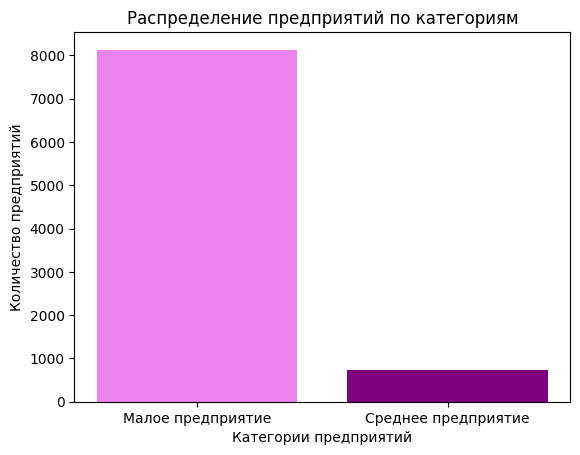

In [1395]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cnt = pd.DataFrame(r_a['Категория'].value_counts())
cat_cnt = cat_cnt.reset_index()
cat_cnt.rename(columns={'count': 'Количество предприятий'}, inplace=True)

plt.bar(cat_cnt['Категория'], cat_cnt['Количество предприятий'], color=['violet', 'purple'])
plt.title('Распределение предприятий по категориям')
plt.xlabel('Категории предприятий')
plt.ylabel('Количество предприятий')
plt.show()

Большая часть предприятий относится к малым, малых предприятий в 11 раз больше, чем средних (малые предприятия - до 100 человек)

In [1397]:
lic_cnt = r_a['Наличие лицензий'].value_counts()
lic_cnt = lic_cnt.reset_index()
lic_cnt.columns = ['Наличие лицензий', 'Количество предприятий']
lic_cnt['Наличие лицензий'] = lic_cnt['Наличие лицензий'].map({False: 'Нет лицензии', True: 'Есть лицензия'})

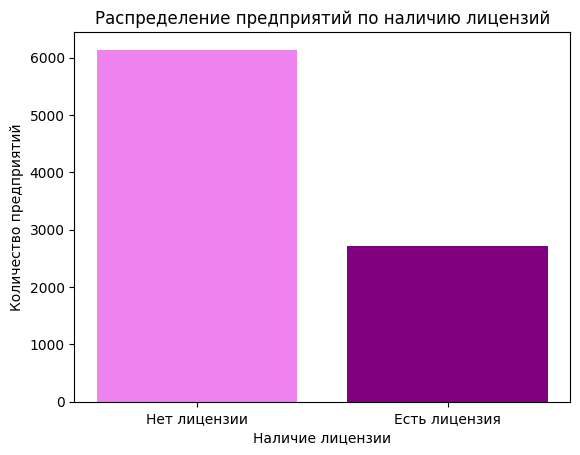

<Figure size 800x600 with 0 Axes>

In [1398]:
plt.bar(lic_cnt['Наличие лицензий'], lic_cnt['Количество предприятий'], color=['violet', 'purple'])
plt.title('Распределение предприятий по наличию лицензий')
plt.xlabel('Наличие лицензии')
plt.ylabel('Количество предприятий')
plt.figure(figsize=(8,6))
plt.show()

Две третих компаний не имеют лицензий, наличие лицензии не критично, так как    
в России с 1 января 2010 года отменено лицензирование строительной деятельности, вместо этого необходимо получать допуск СРО,   
в реестре ФНС информация по наличию допуска отсутствует

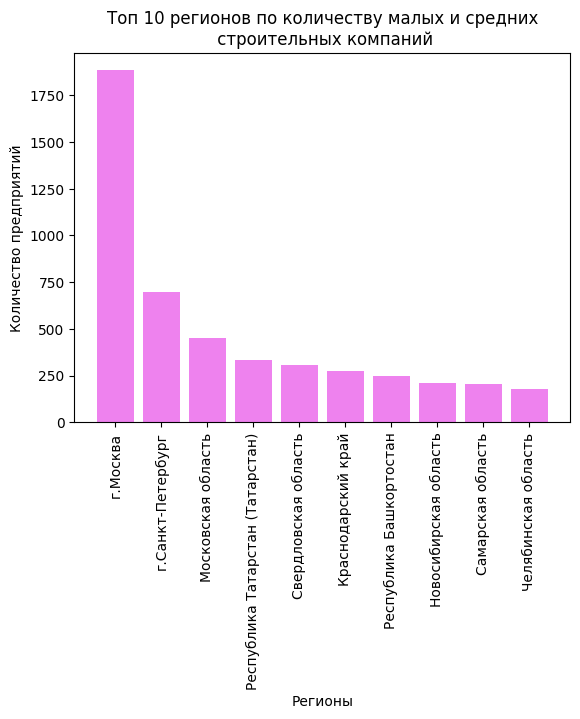

In [630]:
sub_count = pd.DataFrame(r_a['Регион'].value_counts()[:10])
sub_count = sub_count.reset_index()
plt.bar(sub_count['Регион'], sub_count['count'], color='violet')
plt.title('Топ 10 регионов по количеству малых и средних\n строительных компаний')
plt.xlabel('Регионы')
plt.ylabel('Количество предприятий')
plt.xticks(rotation=90)
plt.show()

По количеству компаний ожидаемо лидируют наиболее населенные и развитые регионы страны, где сосредоточена наибольшая часть каких-либо производств,    
с лучшей экономикой

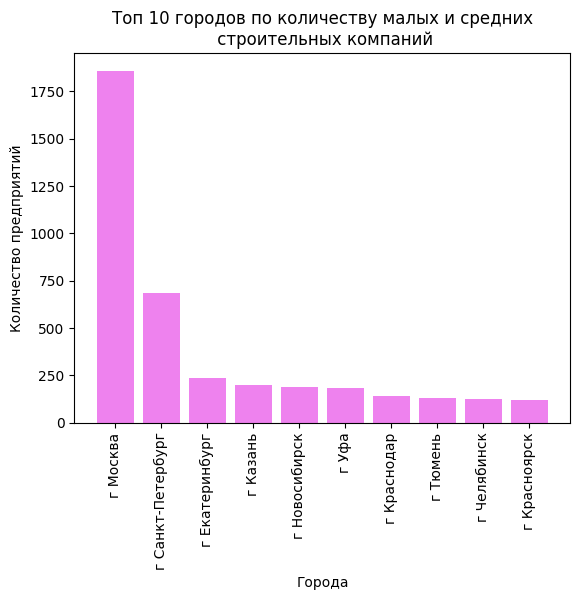

In [631]:
sub_count = pd.DataFrame(r_a['Город или населенный пункт'].value_counts()[:10])
sub_count = sub_count.reset_index()
plt.bar(sub_count['Город или населенный пункт'], sub_count['count'], color='violet')
plt.title('Топ 10 городов по количеству малых и средних\n строительных компаний')
plt.xlabel('Города')
plt.ylabel('Количество предприятий')
plt.xticks(rotation=90)
plt.show()

По количеству компаний ожидаемо лидируют самые экономически-развитые города, являющиеся также столицами регионов или областей,   
что говорит о централизации экономики и денег в столичных городах, особенно в Москве

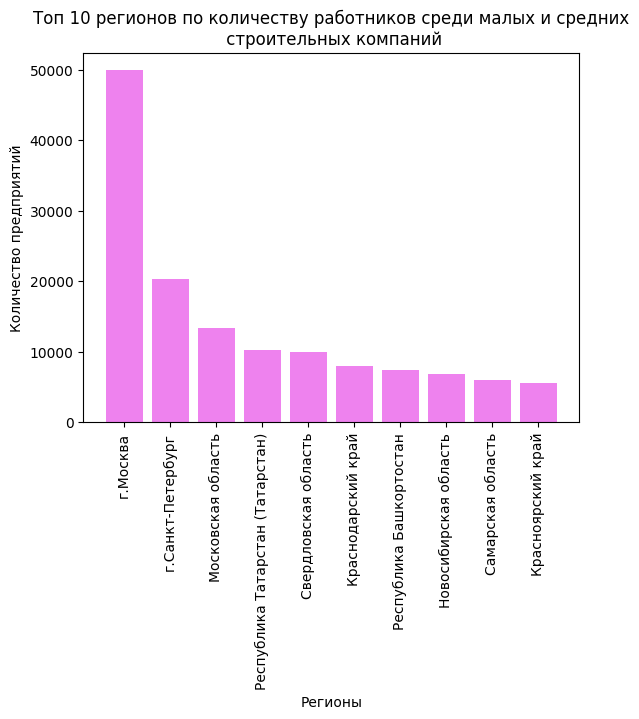

In [632]:
wor_count = pd.DataFrame(r_a.groupby('Регион')['Среднесписочная численность работников за предшествующий календарный год'].sum()).reset_index()
wor_count = wor_count.sort_values('Среднесписочная численность работников за предшествующий календарный год', ascending=False)[:10]
plt.bar(wor_count['Регион'], wor_count['Среднесписочная численность работников за предшествующий календарный год'], color='violet')
plt.title('Топ 10 регионов по количеству работников среди малых и средних\n строительных компаний')
plt.xlabel('Регионы')
plt.ylabel('Количество предприятий')
plt.xticks(rotation=90)
plt.show()

Распределение работников по городам соответствует распределению количества компаний, значит соотношение по численности работников между городами
примерно одинаковое

In [1400]:
r_a['Год регистрации'] = r_a['Дата включения в реестр'].dt.year
reg_year = (pd.DataFrame(r_a['Год регистрации'].value_counts()).sort_index()).reset_index()

Text(0.5, 1.0, 'Динамика включения в реестр по годам')

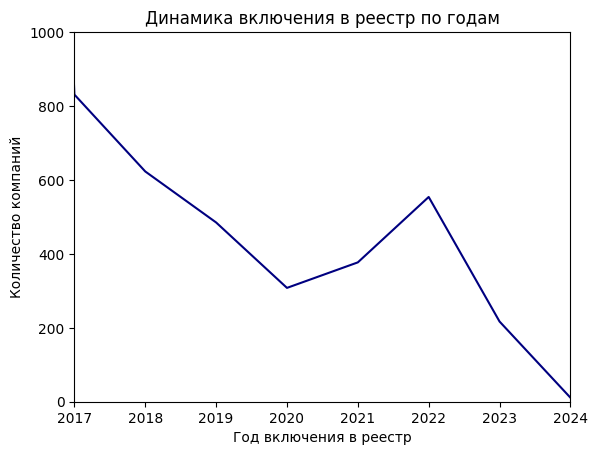

In [1401]:
plt.plot(reg_year['Год регистрации'], reg_year['count'], color='navy')
plt.xlim(2017, 2024)
plt.ylim(0, 1000)
plt.xlabel('Год включения в реестр')
plt.ylabel('Количество компаний')
plt.title('Динамика включения в реестр по годам')

На графике убран 2016 год, так как 2016 год - момент, когда появился портал и данные активно начали вносисться в реестр,   
по приведенному графику можно сказать, что темпы роста регистрации новых компаний в реестре снижались до 2020 года, после чего произошел рост,  
что может быть связано с ковидом (так как предположительно, спрос на жилые дома мог вырасти, ковид показал людям нестабильность современного мира, что могло привести к желанию приобрести капитал в виде недвижимости, также открылись возможности в виде удаленной работы и многие стали готовы переехать   
за город - создался большой спрос), далее после 2022 года произошло падение регистрации новых компаний, экономика перестала расти, начали подниматься ставки по кредитам, что могло сильно повлиять на темпы появления новых компаний

In [1402]:
r_a['Среднесписочная численность работников за предшествующий календарный год'].value_counts().head(10)

Среднесписочная численность работников за предшествующий календарный год
1.0     456
16.0    264
0.0     245
17.0    240
19.0    228
18.0    223
12.0    222
2.0     218
5.0     215
20.0    214
Name: count, dtype: int64

In [1403]:
r_a['Среднесписочная численность работников за предшествующий календарный год'].value_counts()
r_a_c = r_a[r_a['Среднесписочная численность работников за предшествующий календарный год'] > 1]

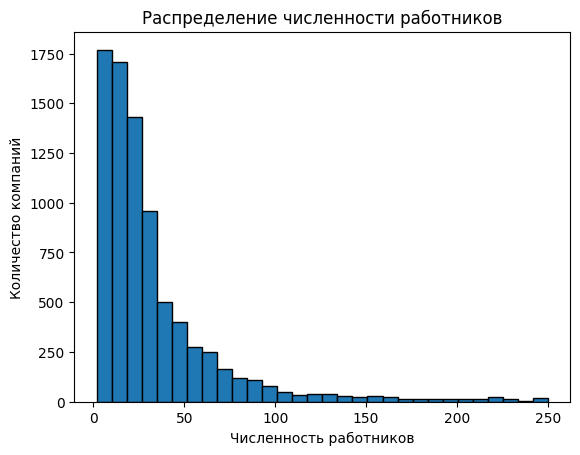

In [1404]:
from scipy import stats
plt.hist(r_a_c['Среднесписочная численность работников за предшествующий календарный год'], bins=30, edgecolor='black')
plt.title('Распределение численности работников')
plt.xlabel('Численность работников')
plt.ylabel('Количество компаний')
plt.show()

Большая часть компаний имеет штат до 100 человек, что согласуется с тем, что большинство компаний - малые предприятия   
Данные по компаниям имеющим 0 человек в штате отфильтрованы, так как в компании должен быть хотя бы 1 человек, это ошибка заполнения

<h2 style='color: #9b59b6; font-weight: bold;'>Парсинг данных</h2>

Получим финансовые показатели для выбранных компаний на основе данных, представленных на сайте https://bo.nalog.gov.ru

In [650]:
r_inn = list(r_a['ИНН'])

In [651]:
import requests
import pandas as pd
import time
import json

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
    'Referer': 'https://bo.nalog.gov.ru/',
    'Origin': 'https://bo.nalog.gov.ru'
}

session = requests.Session()
session.headers.update(headers)

def get_company_id(inn):
    url = f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0&size=20"
    
    try:
        response = session.get(url, timeout=10)
        
        # Проверяем статус
        if response.status_code != 200:
            print(f"  HTTP {response.status_code} для ИНН {inn}")
            return None
        
        # Проверяем, не пустой ли ответ
        if not response.text or response.text.strip() == '':
            print(f"  Пустой ответ для ИНН {inn}")
            return None
        
        # Пробуем распарсить JSON
        data = response.json()
        
        if data.get('content') and len(data['content']) > 0:
            return data['content'][0]['id']
        else:
            print(f"  Организация не найдена для ИНН {inn}")
            return None
            
    except requests.exceptions.RequestException as e:
        print(f"  Сетевая ошибка для ИНН {inn}: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"  Ошибка JSON для ИНН {inn}: {e}")
        print(f"  Первые 200 символов ответа: {response.text[:200]}")
        return None

def get_financial_data(company_id, inn):
    url = f"https://bo.nalog.gov.ru/nbo/organizations/{company_id}/bfo"
    
    try:
        response = session.get(url, timeout=10)
        
        if response.status_code != 200:
            print(f"  HTTP {response.status_code} для ID {company_id}")
            return []
        
        if not response.text or response.text.strip() == '':
            print(f"  Пустой ответ для ID {company_id}")
            return []
        
        data = response.json()
        
        # Если пришел массив
        if isinstance(data, list):
            return data
        # Если пришел словарь с ошибкой
        elif isinstance(data, dict) and data.get('error'):
            print(f"  Ошибка API: {data.get('error')}")
            return []
        else:
            return data if isinstance(data, list) else []
            
    except Exception as e:
        print(f"  Ошибка при получении данных для ID {company_id}: {e}")
        return []

inn_list = r_inn  # список ИНН

results = []

for idx, inn in enumerate(inn_list):
    print(f"\n[{idx+1}/{len(inn_list)}] Обработка ИНН: {inn}")
    
    try:
        # Получаем ID организации
        company_id = get_company_id(inn)
        
        if company_id:
            print(f"  Найден ID: {company_id}")
            
            # Получаем отчетность
            reports = get_financial_data(company_id, inn)
            
            for report in reports:
                # Безопасно извлекаем financialResult
                fr = {}
                balance = {}
                if report.get('typeCorrections') and len(report['typeCorrections']) > 0:
                    correction = report['typeCorrections'][0].get('correction', {})
                    fr = correction.get('financialResult', {})
                    balance = correction.get('balance', {})
                    results.append({
                        'inn': inn,
                        'period': report.get('period'),
                        'gainSum': report.get('gainSum'),                    # Выручка
                        'actives': report.get('actives'),                    # Активы 
                        'profit_before_tax': fr.get('current2300'),          # Прибыль до налогообложения
                        'interest_payable': fr.get('current2330'),           # Проценты к уплате
                        'income_tax': fr.get('current2410'),                 # Налог на прибыль
                        'profit_from_sales': fr.get('current2200'),          # Прибыль от продаж
                        # Для оценки амортизации (из баланса)
                        'fixed_assets_current': balance.get('current1150'),  # Основные средства на конец года
                        'fixed_assets_previous': balance.get('previous1150'),# Основные средства на начало
                        # Дополнительные показатели для анализа
                        'cost_of_sales': fr.get('current2120'),              # Себестоимость
                        'net_profit': fr.get('current2400'),                 # Чистая прибыль
                    })
    except Exception as e:
        print(f"  Критическая ошибка: {e}")
        
    time.sleep(0.5)

if results:
    df = pd.DataFrame(results)
    current_year = 2026
    df['period'] = pd.to_numeric(df['period'], errors='coerce')
    df_recent = df[df['period'] >= current_year - 5]
    
    df_recent.to_excel('financial_data.xlsx', index=False)
    print(f"Собрано данных: {len(df_recent)} записей")
    print(f"Сохранено в financial_data.xlsx")
else:
    print("Нет данных для сохранения")


[1/8859] Обработка ИНН: 5038038838
  Найден ID: 5872486

[2/8859] Обработка ИНН: 5027006369
  Найден ID: 6900709

[3/8859] Обработка ИНН: 1414006922
  Найден ID: 4980670

[4/8859] Обработка ИНН: 3327332190
  Найден ID: 3867230

[5/8859] Обработка ИНН: 7816061297
  Найден ID: 7041303

[6/8859] Обработка ИНН: 3525048992
  Найден ID: 6840082

[7/8859] Обработка ИНН: 3101000612
  Найден ID: 7244164

[8/8859] Обработка ИНН: 5902126804
  Найден ID: 2608351

[9/8859] Обработка ИНН: 523005733
  Найден ID: 4659067

[10/8859] Обработка ИНН: 7724745755
  Найден ID: 2083796

[11/8859] Обработка ИНН: 504007693
  Найден ID: 5591507

[12/8859] Обработка ИНН: 2901030646
  Найден ID: 1410906

[13/8859] Обработка ИНН: 7709008852
  Найден ID: 6462814

[14/8859] Обработка ИНН: 3811167535
  Найден ID: 7906828

[15/8859] Обработка ИНН: 7810255553
  Найден ID: 5028116

[16/8859] Обработка ИНН: 1011005108
  Найден ID: 91738

[17/8859] Обработка ИНН: 2310111297
  Найден ID: 6320206

[18/8859] Обработка ИНН: 3

In [652]:
fin_info = pd.read_excel('financial_data.xlsx')

In [653]:
fin_info.shape

(38993, 12)

In [1405]:
fin_info_t = fin_info.copy()
fin_info_t

,inn,period,gainSum,actives,profit_before_tax,interest_payable,income_tax,profit_from_sales,fixed_assets_current,fixed_assets_previous,cost_of_sales,net_profit
0,5038038838,2025,140064.0,893097.0,-457.0,11869.0,-63.0,355.0,405102.0,347613.0,103274.0,-520.0
1,5038038838,2024,112540.0,768763.0,-19938.0,1521.0,-191.0,-8789.0,347613.0,334651.0,95619.0,-20129.0
2,5038038838,2023,108966.0,804911.0,-20665.0,3334.0,-248.0,-8093.0,334651.0,397311.0,90500.0,-20913.0
3,5038038838,2022,118633.0,885623.0,20219.0,141.0,-336.0,2396.0,397311.0,419266.0,83747.0,19518.0
4,5038038838,2021,184044.0,959613.0,3430.0,5601.0,-320.0,-5813.0,419266.0,533831.0,150023.0,3080.0
...,...,...,...,...,...,...,...,...,...,...,...,...
38988,702005585,2025,10679.0,43649.0,NaN,NaN,-138.0,NaN,24639.0,23742.0,12208.0,413.0
38989,702005585,2024,18397.0,43286.0,NaN,NaN,277.0,NaN,23742.0,5594.0,17011.0,1030.0
38990,702005585,2023,5049.0,37515.0,NaN,NaN,188.0,NaN,5594.0,7070.0,4000.0,750.0
38991,702005585,2022,36804.0,47708.0,2318.0,NaN,-464.0,916.0,7120.0,15156.0,14374.0,-2233.0


In [1406]:
rename_columns = {
    'inn': 'ИНН',
    'period': 'Отчетный_год',
    'gainSum': 'Выручка_тыс_руб',
    'actives': 'Активы_тыс_руб',
    'profit_before_tax': 'Прибыль_до_налогообложения_тыс_руб',
    'interest_payable': 'Проценты_к_уплате_тыс_руб',
    'income_tax': 'Налог_на_прибыль_тыс_руб',
    'profit_from_sales': 'Прибыль_от_продаж_тыс_руб',
    'fixed_assets_current': 'Основные_средства_на_конец_года_тыс_руб',
    'fixed_assets_previous': 'Основные_средства_на_начало_года_тыс_руб',
    'revenue': 'Выручка_альтернативная_тыс_руб',
    'cost_of_sales': 'Себестоимость_продаж_тыс_руб',
    'net_profit': 'Чистая_прибыль_тыс_руб'
}
fin_info_t = fin_info_t.rename(columns=rename_columns)
fin_info_t

,ИНН,Отчетный_год,Выручка_тыс_руб,Активы_тыс_руб,Прибыль_до_налогообложения_тыс_руб,Проценты_к_уплате_тыс_руб,Налог_на_прибыль_тыс_руб,Прибыль_от_продаж_тыс_руб,Основные_средства_на_конец_года_тыс_руб,Основные_средства_на_начало_года_тыс_руб,Себестоимость_продаж_тыс_руб,Чистая_прибыль_тыс_руб
0,5038038838,2025,140064.0,893097.0,-457.0,11869.0,-63.0,355.0,405102.0,347613.0,103274.0,-520.0
1,5038038838,2024,112540.0,768763.0,-19938.0,1521.0,-191.0,-8789.0,347613.0,334651.0,95619.0,-20129.0
2,5038038838,2023,108966.0,804911.0,-20665.0,3334.0,-248.0,-8093.0,334651.0,397311.0,90500.0,-20913.0
3,5038038838,2022,118633.0,885623.0,20219.0,141.0,-336.0,2396.0,397311.0,419266.0,83747.0,19518.0
4,5038038838,2021,184044.0,959613.0,3430.0,5601.0,-320.0,-5813.0,419266.0,533831.0,150023.0,3080.0
...,...,...,...,...,...,...,...,...,...,...,...,...
38988,702005585,2025,10679.0,43649.0,NaN,NaN,-138.0,NaN,24639.0,23742.0,12208.0,413.0
38989,702005585,2024,18397.0,43286.0,NaN,NaN,277.0,NaN,23742.0,5594.0,17011.0,1030.0
38990,702005585,2023,5049.0,37515.0,NaN,NaN,188.0,NaN,5594.0,7070.0,4000.0,750.0
38991,702005585,2022,36804.0,47708.0,2318.0,NaN,-464.0,916.0,7120.0,15156.0,14374.0,-2233.0


В виду отсутствия данных об амортизации будем считать EBITDA следующим образом:   
**EBITDA = Прибыль_до_налогообложения_тыс_руб + Проценты к уплате + Амортизация**  
В качестве амортизации возьмем 8% от среднегодовой стоимости основных средств, т.к. в строительстве   
основные средства (экскаваторы, краны, бетонные заводы) обычно амортизируются в среднем на 8-12% в год   

**Среднегодовые_ОС = (Основные_средства_на_начало_года + Основные_средства_на_конец_года) / 2**   
**Оценочная_амортизация = Среднегодовые_ОС × 0,08**

In [964]:
#проценты к уплате если и указаны, всегда должны быть отрицательными
mask = (fin_info_t['Проценты_к_уплате_тыс_руб'] > 0)
fin_info_t.loc[mask, 'Проценты_к_уплате_тыс_руб'] = -fin_info_t.loc[mask, 'Проценты_к_уплате_тыс_руб']

In [1407]:
#Налог если и указан, всегда должны быть отрицательным
mask = (fin_info_t['Налог_на_прибыль_тыс_руб'] > 0)
fin_info_t.loc[mask, 'Налог_на_прибыль_тыс_руб'] = -fin_info_t.loc[mask, 'Налог_на_прибыль_тыс_руб']

In [1408]:
fin_info_t.columns

Index(['ИНН', 'Отчетный_год', 'Выручка_тыс_руб', 'Активы_тыс_руб',
       'Прибыль_до_налогообложения_тыс_руб', 'Проценты_к_уплате_тыс_руб',
       'Налог_на_прибыль_тыс_руб', 'Прибыль_от_продаж_тыс_руб',
       'Основные_средства_на_конец_года_тыс_руб',
       'Основные_средства_на_начало_года_тыс_руб',
       'Себестоимость_продаж_тыс_руб', 'Чистая_прибыль_тыс_руб'],
      dtype='str')

In [1409]:
#проверяем отсутствие данных
fin_info_t.isnull().sum()

ИНН                                             0
Отчетный_год                                    0
Выручка_тыс_руб                              1282
Активы_тыс_руб                                  3
Прибыль_до_налогообложения_тыс_руб          15748
                                            ...  
Прибыль_от_продаж_тыс_руб                   15857
Основные_средства_на_конец_года_тыс_руб      5004
Основные_средства_на_начало_года_тыс_руб     7299
Себестоимость_продаж_тыс_руб                 1278
Чистая_прибыль_тыс_руб                        478
Length: 12, dtype: int64

Так как данных для рассчета EBITDA критически мало, постараемся сделать вывод о перспективности отрасли по **прибыли от продаж**, так   
как этот показатель показывает прибыль именно от строительной деятельности, отдельно вычислим значение показателя EBITDA для того небольшого количества компаний, по которым имеются данные, определим есть ли разница между изменениями прибыли от продаж по годам на большем количестве данных и в показатели EBITDА на меньшем количестве данных, предположительно - характер их изменения должен быть примерно одинаковый

In [1410]:
#уберем все данные за 2026 год - так как их еще не может быть
fin_info_t['Отчетный_год'].value_counts()

Отчетный_год
2022    8666
2021    8358
2023    8190
2024    7675
2025    6102
2026       2
Name: count, dtype: int64

In [1411]:
fin_pivot = fin_info_t[fin_info_t['Отчетный_год'] <= 2025]
fin_pivot['Отчетный_год'].value_counts()

Отчетный_год
2022    8666
2021    8358
2023    8190
2024    7675
2025    6102
Name: count, dtype: int64

In [1412]:
#смотрим на прибыль_от_продаж
fin_pivot = fin_pivot.pivot(index='ИНН', columns='Отчетный_год', values='Прибыль_от_продаж_тыс_руб').reset_index()
fin_pivot = fin_pivot.dropna()
fin_pivot = fin_pivot.reset_index(drop=True)
fin_pivot = fin_pivot.rename(columns={2022: '2022', 2023: '2023', 2024: '2024', 2025: '2025'})
fin_pivot

Отчетный_год,ИНН,2021,2022,2023,2024,2025
0,101009232,3326.0,19175.0,22025.0,18641.0,42531.0
1,105008695,-7324.0,8574.0,2096.0,41233.0,64075.0
2,105027747,68060.0,24221.0,53865.0,37536.0,27196.0
3,105037625,11427.0,-367.0,461.0,8436.0,-1063.0
4,105055159,-3134.0,22621.0,22825.0,-3099.0,229.0
...,...,...,...,...,...,...
2694,9729011159,49407.0,109397.0,147109.0,77917.0,132977.0
2695,9729109612,-3070.0,5409.0,48995.0,78760.0,8648.0
2696,9729161637,36237.0,119882.0,115452.0,74350.0,-29679.0
2697,9731014414,13528.0,3151.0,-117626.0,78688.0,100837.0


In [1413]:
r_a = r_a.astype({'ИНН': 'int'})

In [1414]:
fin_pivot = fin_pivot.astype('int')
fin_pivot.dtypes

Отчетный_год
ИНН     int64
2021    int64
2022    int64
2023    int64
2024    int64
2025    int64
dtype: object

In [1415]:
#теперь объединим таблицы и проанализируем
r_a_pr = pd.merge(fin_pivot, r_a, on='ИНН', how='left')
r_a_pr

,ИНН,2021,2022,2023,2024,2025,Наименование / ФИО,Категория,ОГРН,Код региона,Регион,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год,Год регистрации
0,101009232,3326,19175,22025,18641,42531,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""КРА...",Малое предприятие,1090101000660,1,Республика Адыгея (Адыгея),с Красногвардейское,2016-01-08,False,70.0,2016
1,105008695,-7324,8574,2096,41233,64075,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПЕЦ...",Малое предприятие,1020100702643,1,Республика Адыгея (Адыгея),г Майкоп,2016-01-08,False,42.0,2016
2,105027747,68060,24221,53865,37536,27196,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МАРК...",Малое предприятие,1020100710024,1,Республика Адыгея (Адыгея),г Майкоп,2016-01-08,False,60.0,2016
3,105037625,11427,-367,461,8436,-1063,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МОНО...",Малое предприятие,1020100694833,1,Республика Адыгея (Адыгея),г Майкоп,2016-01-08,False,18.0,2016
4,105055159,-3134,22621,22825,-3099,229,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Малое предприятие,1080105001921,1,Республика Адыгея (Адыгея),г Майкоп,2016-01-08,False,41.0,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2694,9729011159,49407,109397,147109,77917,132977,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""КАРС...",Малое предприятие,1167746542270,77,г.Москва,г Москва,2016-01-08,False,11.0,2016
2695,9729109612,-3070,5409,48995,78760,8648,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ВИТЯЗЬ""",Малое предприятие,1177746717422,77,г.Москва,г Москва,2017-10-08,True,50.0,2017
2696,9729161637,36237,119882,115452,74350,-29679,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Среднее предприятие,5177746146078,77,г.Москва,г Москва,2022-10-06,False,74.0,2022
2697,9731014414,13528,3151,-117626,78688,100837,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СВЯЗ...",Малое предприятие,1187746909151,77,г.Москва,г Москва,2018-10-12,False,63.0,2018


In [1416]:
r_a_pr.columns = r_a_pr.columns.astype(str)

In [1417]:
#посмотрим на основные показатели статистик
pd.set_option('display.float_format', '{:.0f}'.format)
r_a_pr[['2021', '2022', '2023', '2024', '2025']].describe()

,2021,2022,2023,2024,2025
count,2699,2699,2699,2699,2699
mean,21028,23927,31575,34338,34489
std,272833,88631,125931,135023,206095
min,-11435265,-409795,-691308,-497439,-751439
25%,541,331,108,-2,-1036
50%,4992,5847,6113,5506,3336
75%,20602,24214,29070,29688,23756
max,7038450,1937927,3252731,3431288,5250790


Заметим, что медианное значение очень сильно отличается от среднего, так как имееются сильные выбросы - компании с большими убытками или большой прибылью, заметим что медианное значение прибыли от продаж снижается год от года, но среднее растет - это говорит о том, что в среднем в последние годы экономическая ситуация отражается на строительном бизнесе плохо, снижается прибыльность бизнеса, но тем не менее гиганты продолжают расти и увеличивать прибыль

In [1418]:
pd.reset_option('display.float_format')

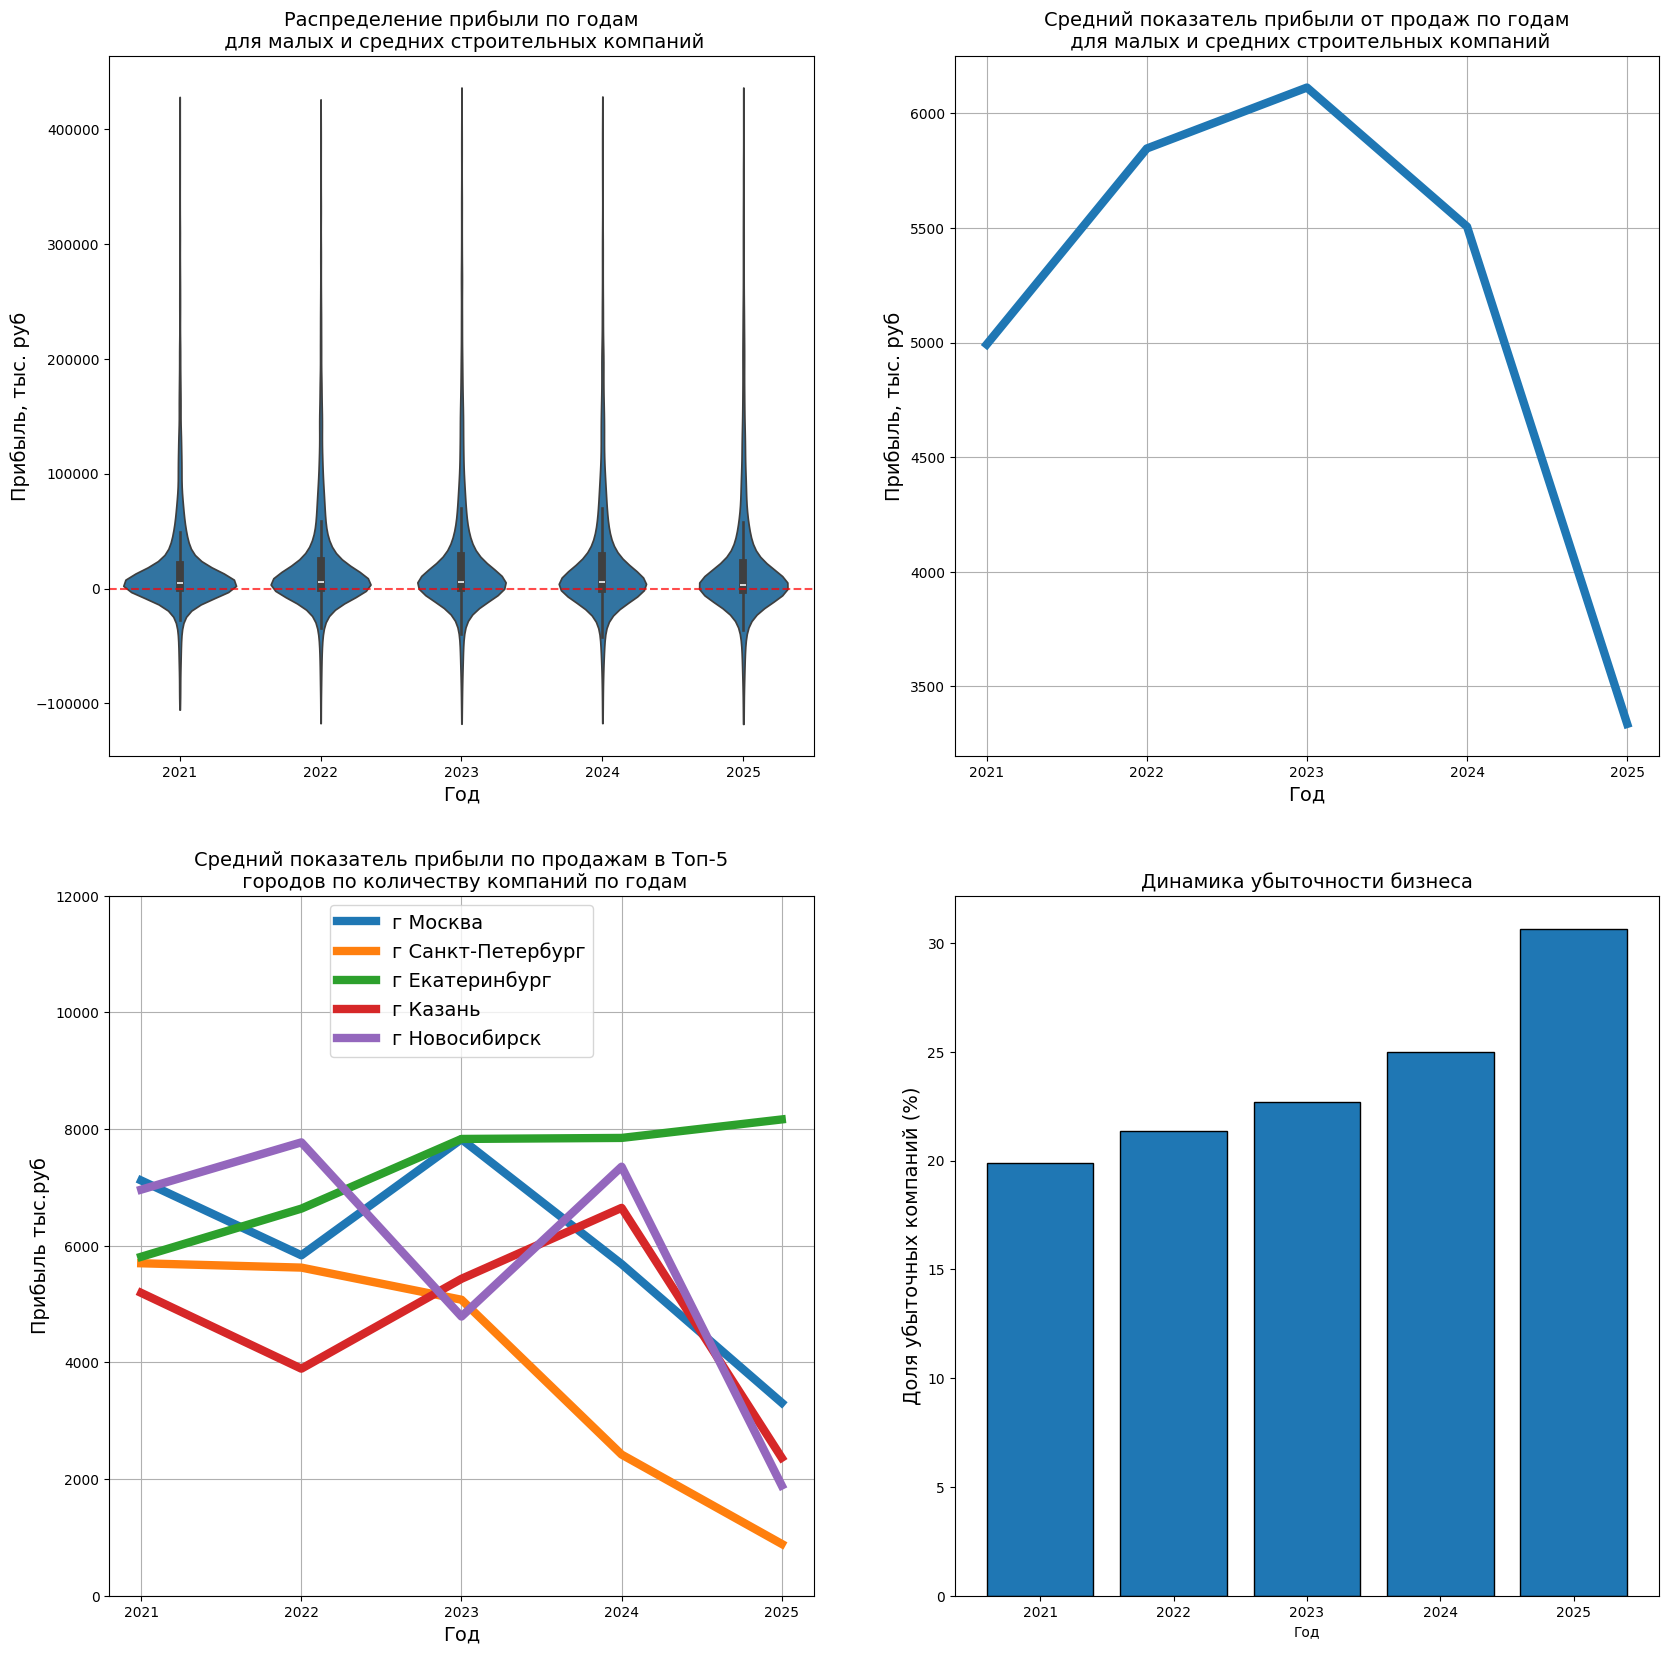

In [1419]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 20))

years = ['2021', '2022', '2023', '2024', '2025']

df_long_pr = pd.melt(
    r_a_pr,  
    id_vars=['ИНН'],  
    value_vars=years,  
    var_name='Год', 
    value_name='Прибыль'  
)
lower = df_long_pr['Прибыль'].quantile(0.01)
upper = df_long_pr['Прибыль'].quantile(0.99)
df_long_filtered_pr = df_long_pr[(df_long_pr['Прибыль'] >= lower) & (df_long_pr['Прибыль'] <= upper)]

#левый верхний
sns.violinplot(data=df_long_filtered_pr, x='Год', y='Прибыль', cut=0, ax=axes[0, 0])
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Распределение прибыли по годам\n для малых и средних строительных компаний', fontsize=14)
axes[0, 0].set_ylabel('Прибыль, тыс. руб', fontsize=14)
axes[0, 0].set_xlabel('Год', fontsize=14)
#правый верхний
median = r_a_pr[years].median()
axes[0, 1].plot(years_cols, median.values, linewidth=6)
axes[0, 1].set_title('Средний показатель прибыли от продаж по годам\n для малых и средних строительных компаний', fontsize=14)
axes[0, 1].set_xlabel('Год', fontsize=14)
axes[0, 1].set_ylabel('Прибыль, тыс. руб', fontsize=14)
axes[0, 1].grid(True)
#левый нижний
for city in list(sub_count['Город или населенный пункт'].head(5)):
    c_t = r_a_pr[r_a_pr['Город или населенный пункт'] == city]
    c_t_median = c_t[years].median()
    axes[1, 0].plot(c_t_median, label=city, linewidth=6)
axes[1, 0].legend(loc='upper center', fontsize='14')
axes[1, 0].grid()
axes[1, 0].set_ylim(0, 12000)
axes[1, 0].set_title('Средний показатель прибыли по продажам в Топ-5\n городов по количеству компаний по годам', fontsize='14')
axes[1, 0].set_xlabel('Год', fontsize='14')
axes[1, 0].set_ylabel('Прибыль тыс.руб', fontsize='14')
#правый нижний
loss_share = []
for year in years:
    data = r_a_pr[year]
    loss_share.append((r_a_pr[year] < 0).sum() / r_a_pr[year].count()* 100)
axes[1, 1].bar(years, loss_share, edgecolor='black')
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Доля убыточных компаний (%)', fontsize='14')
axes[1, 1].set_title('Динамика убыточности бизнеса', fontsize='14')
plt.show()

Данные по прибыли имеют очень большой разброс, прибыли разных компаний в рамках одной и той же категории по крупности бизнеса разнятся до пяти раз   
Прибыль от продаж росла с 2021 по 2022 годы, а затем, предположительно, в связи с началом СВО, ухода иностранных компаний, дестабилизации экономической обстановки, показатели прибыльности начали стремительно падать и особенно заметна разница между 2024 и 2025 годом, также на снижение может влиять повышение налогов и процентов по кредитам в последние годы. Небольшой рост с 2022 по 2023 год может быть связан с тем, что строительная отрасль очень инертная - так как срок реализации проектов может быть долгим, наступление кризиса для этой отрасли часто отстает на 1-2 года   

По самым крупным городам по количеству компаний наблюдается также снижение прибыльности, если до 2024 года в некоторых городах отмечался рост, то после 2024 практически во всех городах показатель упал, иные показатели прибыльности в г. Екатеринбурге могут быть связаны с малым количеством данных по компаниям и не отражать полной картины по прибыльности в конкретном городе. Показатели по г. Москве и г. Санкт-Петерубргу лучше отражают реальность, так как в этих двух городах сосредоточена большая часть компаний

Также можно заметить, что доля тех компаний, которые работают в убыток растет с каждым годом, и сильнее всего с 2024 по 2025 годы

In [1434]:
fin_info_t['Оценочная_амортизация'] = (fin_info_t['Основные_средства_на_конец_года_тыс_руб'] + fin_info_t['Основные_средства_на_начало_года_тыс_руб']) / 2 * 0.08

In [1435]:
fin_info_t = fin_info_t.astype({'Активы_тыс_руб': 'float'})

In [1436]:
fin_info_t['EBITDA'] = fin_info_t['Чистая_прибыль_тыс_руб'] + abs(fin_info_t['Налог_на_прибыль_тыс_руб']) + abs(fin_info_t['Проценты_к_уплате_тыс_руб']) + fin_info_t['Оценочная_амортизация']
fin_info_t

,ИНН,Отчетный_год,Выручка_тыс_руб,Активы_тыс_руб,Прибыль_до_налогообложения_тыс_руб,Проценты_к_уплате_тыс_руб,Налог_на_прибыль_тыс_руб,Прибыль_от_продаж_тыс_руб,Основные_средства_на_конец_года_тыс_руб,Основные_средства_на_начало_года_тыс_руб,Себестоимость_продаж_тыс_руб,Чистая_прибыль_тыс_руб,Оценочная_амортизация,EBITDA
0,5038038838,2025,140064.0,893097.0,-457.0,11869.0,-63.0,355.0,405102.0,347613.0,103274.0,-520.0,30108.60,41520.60
1,5038038838,2024,112540.0,768763.0,-19938.0,1521.0,-191.0,-8789.0,347613.0,334651.0,95619.0,-20129.0,27290.56,8873.56
2,5038038838,2023,108966.0,804911.0,-20665.0,3334.0,-248.0,-8093.0,334651.0,397311.0,90500.0,-20913.0,29278.48,11947.48
3,5038038838,2022,118633.0,885623.0,20219.0,141.0,-336.0,2396.0,397311.0,419266.0,83747.0,19518.0,32663.08,52658.08
4,5038038838,2021,184044.0,959613.0,3430.0,5601.0,-320.0,-5813.0,419266.0,533831.0,150023.0,3080.0,38123.88,47124.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38988,702005585,2025,10679.0,43649.0,NaN,NaN,-138.0,NaN,24639.0,23742.0,12208.0,413.0,1935.24,NaN
38989,702005585,2024,18397.0,43286.0,NaN,NaN,-277.0,NaN,23742.0,5594.0,17011.0,1030.0,1173.44,NaN
38990,702005585,2023,5049.0,37515.0,NaN,NaN,-188.0,NaN,5594.0,7070.0,4000.0,750.0,506.56,NaN
38991,702005585,2022,36804.0,47708.0,2318.0,NaN,-464.0,916.0,7120.0,15156.0,14374.0,-2233.0,891.04,NaN


In [1437]:
#смотрим на EBITDA
fin_pivot_EBITDA = fin_info_t[fin_info_t['Отчетный_год'] <= 2025]
fin_pivot_EBITDA = fin_pivot_EBITDA.pivot(index='ИНН', columns='Отчетный_год', values='EBITDA').reset_index()
fin_pivot_EBITDA = fin_pivot_EBITDA.dropna()
fin_pivot_EBITDA = fin_pivot_EBITDA.reset_index(drop=True)
fin_pivot_EBITDA = fin_pivot_EBITDA.rename(columns={2022: '2022', 2023: '2023', 2024: '2024', 2025: '2025'})
fin_pivot_EBITDA

Отчетный_год,ИНН,2021,2022,2023,2024,2025
0,105027747,73181.28,28392.28,42562.80,41227.60,31359.96
1,105043900,14973.08,24323.76,15733.72,10855.72,-1282.00
2,107027037,91440.88,4583.16,40384.84,-295830.08,149548.24
3,225004830,8863.36,21654.48,15391.88,16200.12,39702.44
4,245021417,9570.32,7215.88,3882.52,4307.52,662.52
...,...,...,...,...,...,...
1165,9718077983,-30752.16,-357.68,-15407.04,1813.96,-192.04
1166,9721072953,32590.32,8603.84,3787.88,2852.84,37337.64
1167,9723045458,17179.92,27197.08,34238.04,27303.32,14837.88
1168,9725001287,4592.60,8641.56,20087.88,8586.80,-12092.60


Заметим, что из почти 9000 компаний у нас осталось только 1170, по которым можно было оценить EBITDA, что не очень хорошо может отражать реальную картину, так как не понятно, насколько такая выборка будет репрезентативна, поэтому воспользуемся с осторожностью

In [1438]:
fin_pivot_EBITDA.columns = fin_pivot_EBITDA.columns.astype(str)

In [1439]:
fin_pivot_EBITDA.dtypes

Отчетный_год
ИНН       int64
2021    float64
2022    float64
2023    float64
2024    float64
2025    float64
dtype: object

In [1441]:
r_a_EBITDA = pd.merge(fin_pivot_EBITDA, r_a, on='ИНН', how='left')
r_a_EBITDA

,ИНН,2021,2022,2023,2024,2025,Наименование / ФИО,Категория,ОГРН,Код региона,Регион,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год,Год регистрации
0,105027747,73181.28,28392.28,42562.80,41227.60,31359.96,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МАРК...",Малое предприятие,1020100710024,1,Республика Адыгея (Адыгея),г Майкоп,2016-01-08,False,60.0,2016
1,105043900,14973.08,24323.76,15733.72,10855.72,-1282.00,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""РЕМС...",Малое предприятие,1040100553130,1,Республика Адыгея (Адыгея),г Майкоп,2016-01-08,False,39.0,2016
2,107027037,91440.88,4583.16,40384.84,-295830.08,149548.24,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ФОРВ...",Малое предприятие,1140107001275,1,Республика Адыгея (Адыгея),аул Тахтамукай,2016-01-08,False,33.0,2016
3,225004830,8863.36,21654.48,15391.88,16200.12,39702.44,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПЕРЕ...",Малое предприятие,1150280017876,2,Республика Башкортостан,с Верхнеяркеево,2016-01-08,False,22.0,2016
4,245021417,9570.32,7215.88,3882.52,4307.52,662.52,ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ПРОМЫ...,Малое предприятие,1100280007497,2,Республика Башкортостан,г Уфа,2016-01-08,True,14.0,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,9718077983,-30752.16,-357.68,-15407.04,1813.96,-192.04,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Среднее предприятие,5177746035165,77,г.Москва,г Москва,2017-10-11,False,2.0,2017
1166,9721072953,32590.32,8603.84,3787.88,2852.84,37337.64,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Среднее предприятие,1187746999879,77,г.Москва,г Москва,2023-10-07,False,42.0,2023
1167,9723045458,17179.92,27197.08,34238.04,27303.32,14837.88,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ТЕХС...",Среднее предприятие,1187746398179,77,г.Москва,г Москва,2018-10-05,True,9.0,2018
1168,9725001287,4592.60,8641.56,20087.88,8586.80,-12092.60,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОЛ...",Малое предприятие,1197746007030,77,г.Москва,г Москва,2019-10-02,False,22.0,2019


In [1442]:
pd.set_option('display.float_format', '{:.0f}'.format)
fin_pivot_EBITDA[['2021', '2022', '2023', '2024', '2025']].describe()

Отчетный_год,2021,2022,2023,2024,2025
count,1170,1170,1170,1170,1170
mean,17690,28862,40869,44353,45772
std,352488,90955,155873,153723,181133
min,-11469410,-920248,-1238109,-1144323,-701295
25%,3140,3695,3712,3693,2697
50%,9520,11606,12206,14671,12220
75%,26038,29873,36704,44806,40986
max,1661122,1254953,3494391,3479312,2699795


Как и в случае с прибылью от продаж среднее и медиана значительно отличаются, разброс данных очень большой

In [1443]:
pd.reset_option('display.float_format')

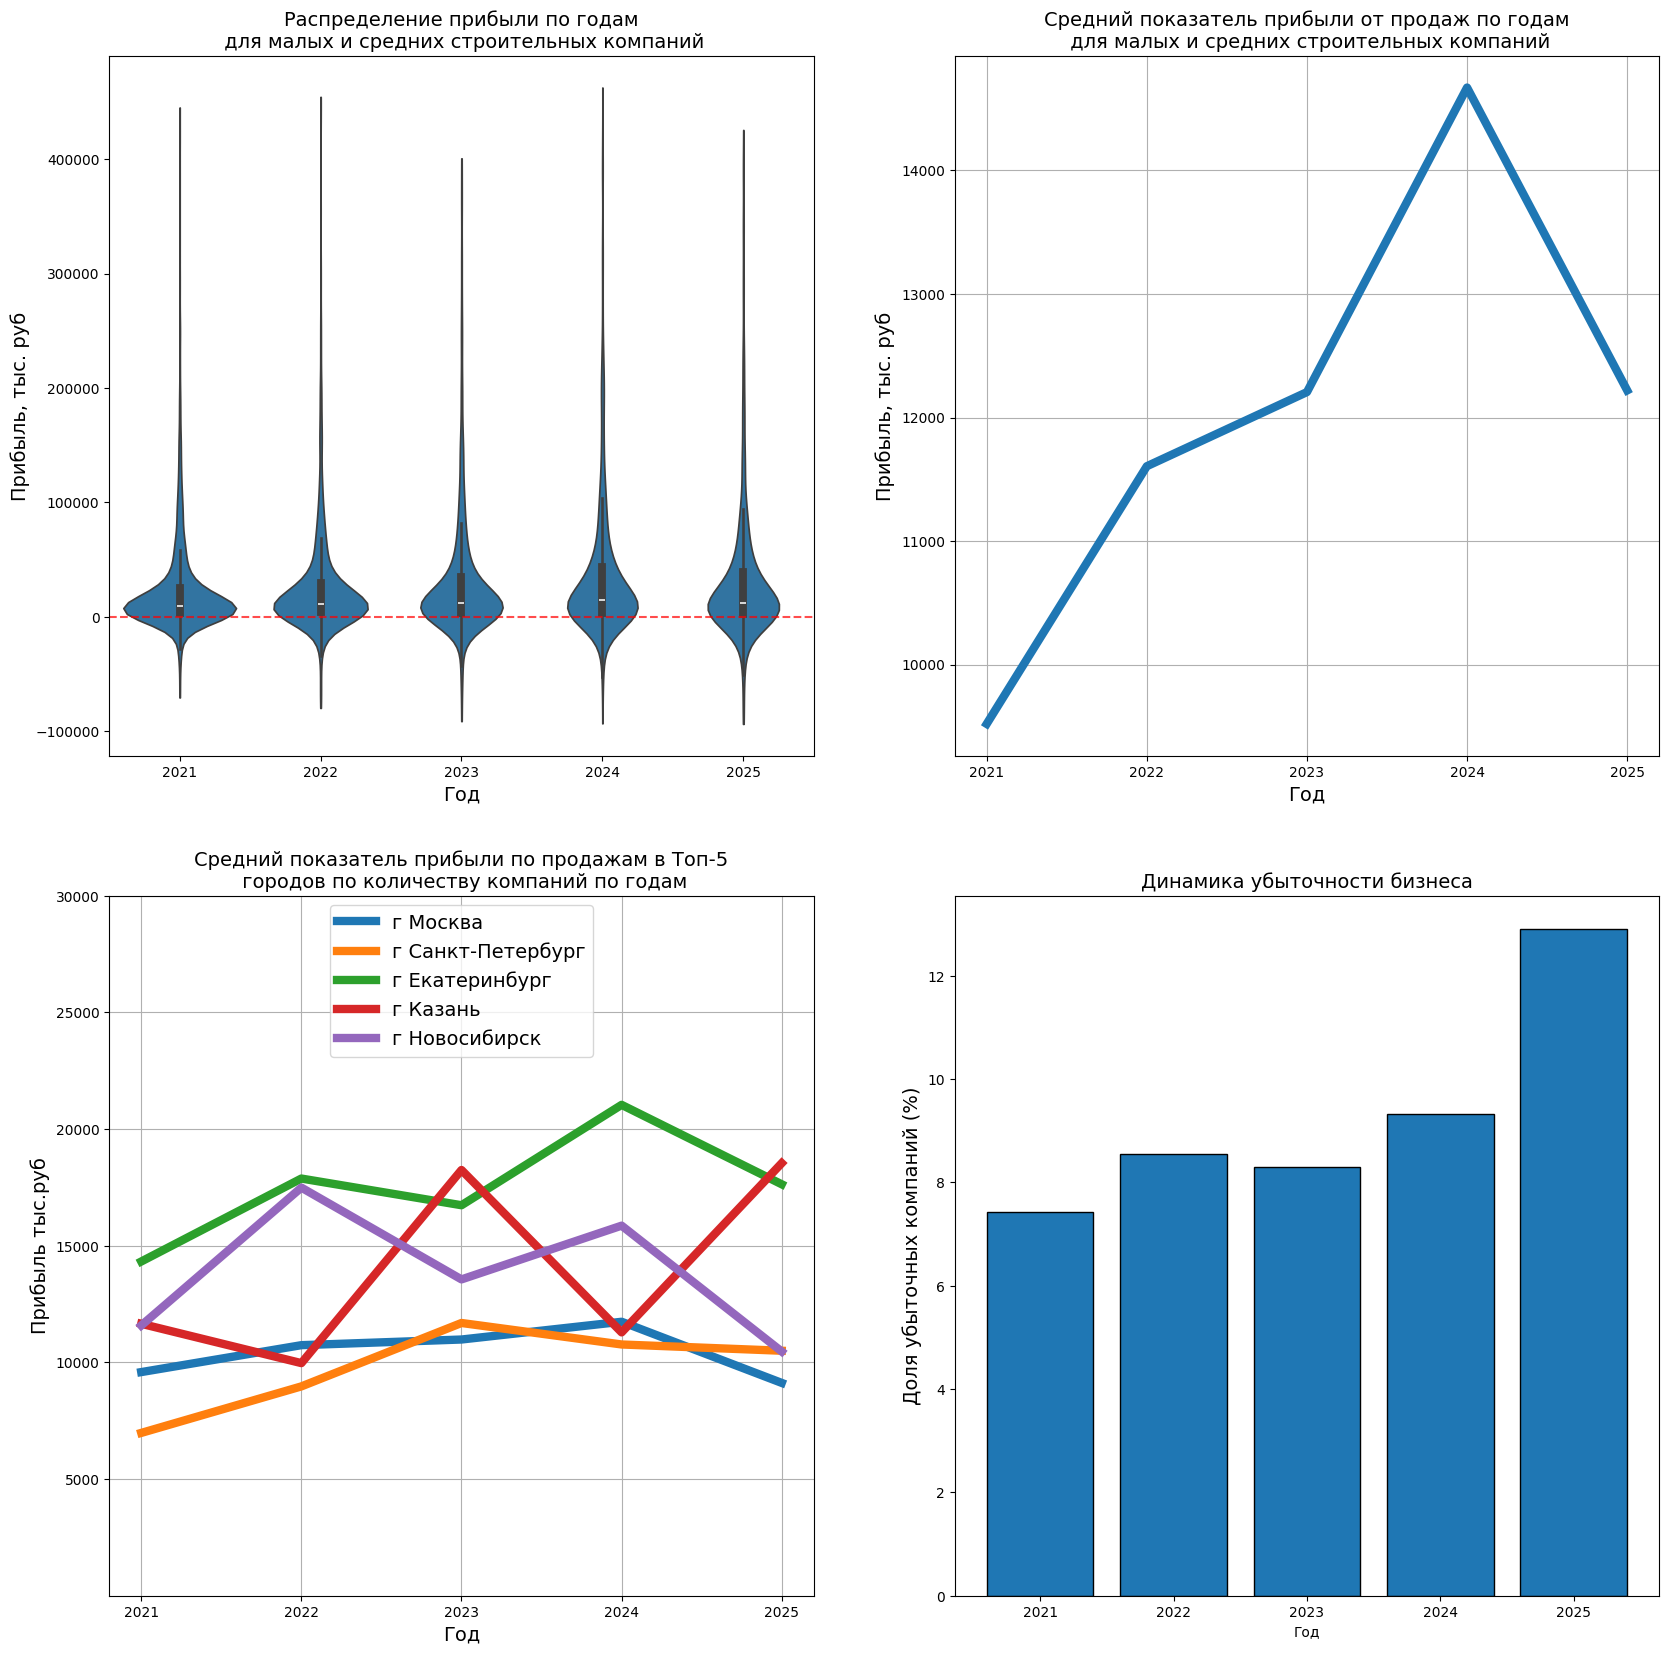

In [1444]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 20))

years = ['2021', '2022', '2023', '2024', '2025']

df_long_pr = pd.melt(
    r_a_EBITDA,  
    id_vars=['ИНН'],  
    value_vars=years,  
    var_name='Год', 
    value_name='Прибыль'  
)
lower = df_long_pr['Прибыль'].quantile(0.01)
upper = df_long_pr['Прибыль'].quantile(0.99)
df_long_filtered_pr = df_long_pr[(df_long_pr['Прибыль'] >= lower) & (df_long_pr['Прибыль'] <= upper)]

#левый верхний
sns.violinplot(data=df_long_filtered_pr, x='Год', y='Прибыль', cut=0, ax=axes[0, 0])
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0, 0].set_title('Распределение прибыли по годам\n для малых и средних строительных компаний', fontsize=14)
axes[0, 0].set_ylabel('Прибыль, тыс. руб', fontsize=14)
axes[0, 0].set_xlabel('Год', fontsize=14)
#правый верхний
median = r_a_EBITDA[years].median()
axes[0, 1].plot(years_cols, median.values, linewidth=6)
axes[0, 1].set_title('Средний показатель прибыли от продаж по годам\n для малых и средних строительных компаний', fontsize=14)
axes[0, 1].set_xlabel('Год', fontsize=14)
axes[0, 1].set_ylabel('Прибыль, тыс. руб', fontsize=14)
axes[0, 1].grid(True)
#левый нижний
for city in list(sub_count['Город или населенный пункт'].head(5)):
    c_t = r_a_EBITDA[r_a_EBITDA['Город или населенный пункт'] == city]
    c_t_median = c_t[years].median()
    axes[1, 0].plot(c_t_median, label=city, linewidth=6)
axes[1, 0].legend(loc='upper center', fontsize='14')
axes[1, 0].grid()
axes[1, 0].set_ylim(6, 30000)
axes[1, 0].set_title('Средний показатель прибыли по продажам в Топ-5\n городов по количеству компаний по годам', fontsize='14')
axes[1, 0].set_xlabel('Год', fontsize='14')
axes[1, 0].set_ylabel('Прибыль тыс.руб', fontsize='14')
#правый нижний
loss_share = []
for year in years:
    data = r_a_EBITDA[year]
    loss_share.append((r_a_EBITDA[year] < 0).sum() / r_a_EBITDA[year].count()* 100)
axes[1, 1].bar(years, loss_share, edgecolor='black')
axes[1, 1].set_xlabel('Год')
axes[1, 1].set_ylabel('Доля убыточных компаний (%)', fontsize='14')
axes[1, 1].set_title('Динамика убыточности бизнеса', fontsize='14')
plt.show()

Заметим, что данные по среднему(медианному) показателю EBITDA по характеру отличаются от прибыли от продаж (что может быть вызвано как и нерепрезантативностью выборки, так и внесением вклада других показателей, которые не включает в себя прибыль от продаж, такие как величина налога, проценты по кредитам - если они выросли, то по сравнению с чистой прибылью может расти и EBITDA из которых он складывается, проверим это далее   

В остальном, характер изменений показателя по годам такой же как и прибыли от продаж, но в случае с изменениям показателя по городам, 
сложно сформулировать вывод, слишком мало данных, нет какой-либо единой тенденции, значения отличаются для разных крупных городов

In [1445]:
fin_info_t_c = fin_info_t.copy()

In [1447]:
fin_info_t_c = fin_info_t[fin_info_t['ИНН'].isin(fin_pivot_EBITDA['ИНН'])]
fin_info_t_c

,ИНН,Отчетный_год,Выручка_тыс_руб,Активы_тыс_руб,Прибыль_до_налогообложения_тыс_руб,Проценты_к_уплате_тыс_руб,Налог_на_прибыль_тыс_руб,Прибыль_от_продаж_тыс_руб,Основные_средства_на_конец_года_тыс_руб,Основные_средства_на_начало_года_тыс_руб,Себестоимость_продаж_тыс_руб,Чистая_прибыль_тыс_руб,Оценочная_амортизация,EBITDA
0,5038038838,2025,140064.0,893097.0,-457.0,11869.0,-63.0,355.0,405102.0,347613.0,103274.0,-520.0,30108.60,41520.60
1,5038038838,2024,112540.0,768763.0,-19938.0,1521.0,-191.0,-8789.0,347613.0,334651.0,95619.0,-20129.0,27290.56,8873.56
2,5038038838,2023,108966.0,804911.0,-20665.0,3334.0,-248.0,-8093.0,334651.0,397311.0,90500.0,-20913.0,29278.48,11947.48
3,5038038838,2022,118633.0,885623.0,20219.0,141.0,-336.0,2396.0,397311.0,419266.0,83747.0,19518.0,32663.08,52658.08
4,5038038838,2021,184044.0,959613.0,3430.0,5601.0,-320.0,-5813.0,419266.0,533831.0,150023.0,3080.0,38123.88,47124.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38943,5410108649,2025,173569.0,902077.0,-7876.0,1102.0,-395.0,12598.0,101057.0,119117.0,116897.0,-8271.0,8806.96,2032.96
38944,5410108649,2024,150529.0,913223.0,-1069.0,1202.0,-105.0,27968.0,119117.0,117094.0,84979.0,-1174.0,9448.44,9581.44
38945,5410108649,2023,102702.0,926432.0,-1728.0,1624.0,-209.0,4850.0,117094.0,120776.0,70443.0,-1937.0,9514.80,9410.80
38946,5410108649,2022,98975.0,945952.0,-4933.0,2194.0,-216.0,6976.0,120776.0,14136.0,60354.0,-5149.0,5396.48,2657.48


In [1448]:
fin_pivot_clear_pr = fin_info_t_c.pivot(index='ИНН', columns='Отчетный_год', values='Чистая_прибыль_тыс_руб').reset_index()
fin_pivot_clear_pr.columns = fin_pivot_clear_pr.columns.astype(str)

In [1449]:
fin_pivot_nal = fin_info_t_c.pivot(index='ИНН', columns='Отчетный_год', values='Налог_на_прибыль_тыс_руб').reset_index()
fin_pivot_nal.columns = fin_pivot_nal.columns.astype(str)
fin_pivot_nal[years] = abs(fin_pivot_nal[years])

In [1450]:
fin_pivot_perc = fin_info_t_c.pivot(index='ИНН', columns='Отчетный_год', values='Проценты_к_уплате_тыс_руб').reset_index()
fin_pivot_perc.columns = fin_pivot_perc.columns.astype(str)
fin_pivot_perc[years] = abs(fin_pivot_perc[years])

In [1451]:
fin_pivot_amor = fin_info_t_c.pivot(index='ИНН', columns='Отчетный_год', values='Оценочная_амортизация').reset_index()
fin_pivot_amor.columns = fin_pivot_amor.columns.astype(str)

In [1452]:
fin_pivot_prod = fin_info_t_c.pivot(index='ИНН', columns='Отчетный_год', values='Прибыль_от_продаж_тыс_руб').reset_index()
fin_pivot_prod.columns = fin_pivot_prod.columns.astype(str)
fin_pivot_prod = fin_pivot_prod.dropna()

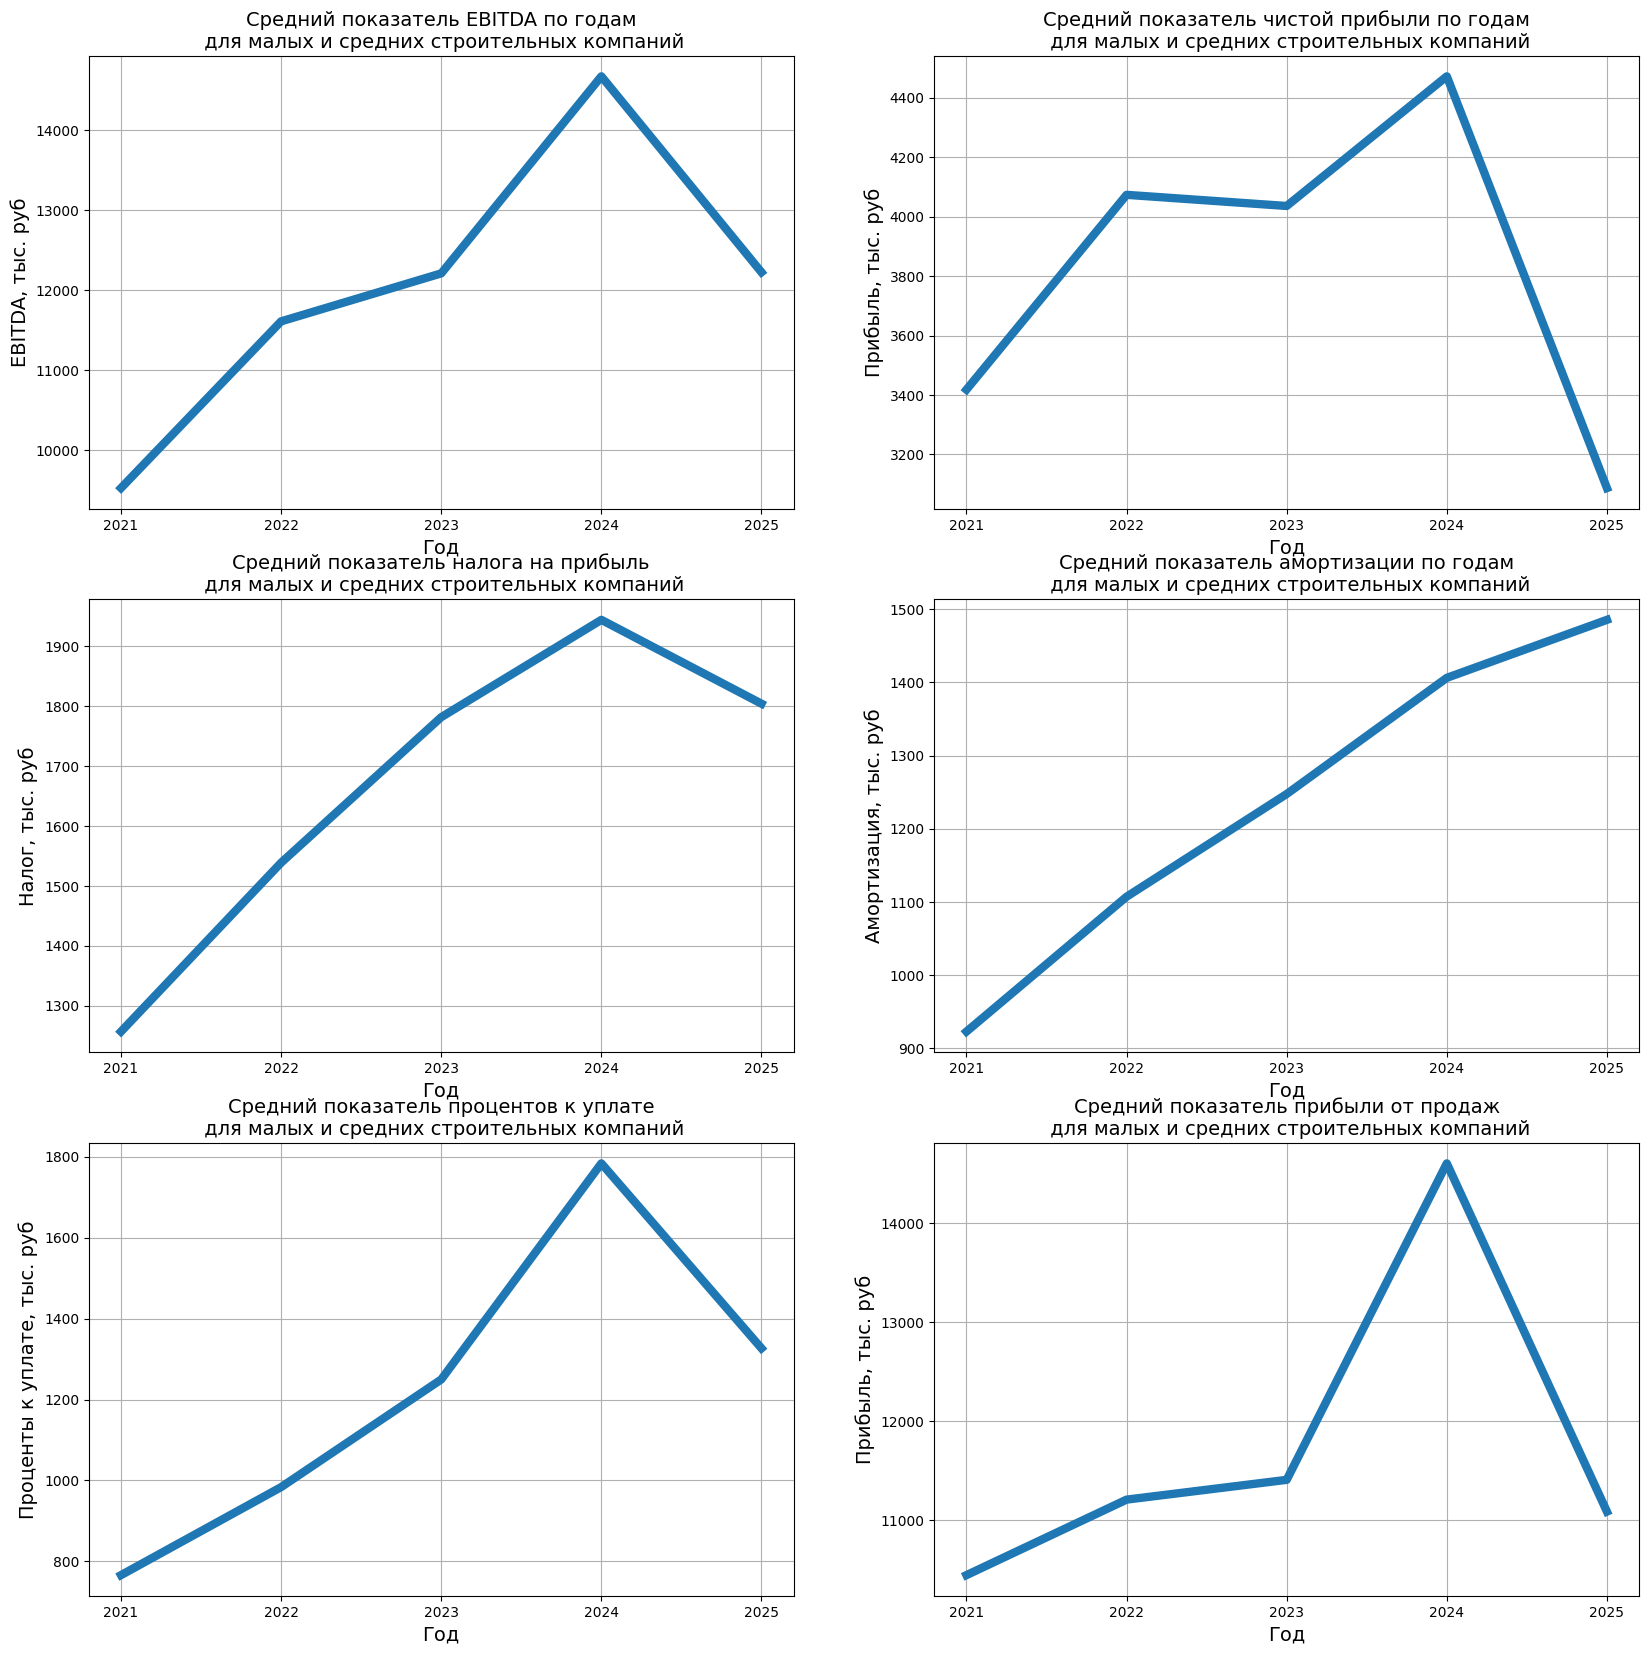

In [1455]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))

#левый верхний
median = r_a_EBITDA[years].median()
axes[0, 0].plot(years_cols, median.values, linewidth=6)
axes[0, 0].set_title('Средний показатель EBITDA по годам\n для малых и средних строительных компаний', fontsize=14)
axes[0, 0].set_xlabel('Год', fontsize=14)
axes[0, 0].set_ylabel('EBITDA, тыс. руб', fontsize=14)
axes[0, 0].grid(True)

#правый верхний
median = fin_pivot_clear_pr[years].median()
axes[0, 1].plot(years_cols, median.values, linewidth=6)
axes[0, 1].set_title('Средний показатель чистой прибыли по годам\n для малых и средних строительных компаний', fontsize=14)
axes[0, 1].set_xlabel('Год', fontsize=14)
axes[0, 1].set_ylabel('Прибыль, тыс. руб', fontsize=14)
axes[0, 1].grid(True)

#левый нижний
median = fin_pivot_nal[years].median()
axes[1, 0].plot(years_cols, median.values, linewidth=6)
axes[1, 0].set_title('Средний показатель налога на прибыль\n для малых и средних строительных компаний', fontsize=14)
axes[1, 0].set_xlabel('Год', fontsize=14)
axes[1, 0].set_ylabel('Налог, тыс. руб', fontsize=14)
axes[1, 0].grid(True)


median = fin_pivot_perc[years].median()
axes[2, 0].plot(years_cols, median.values, linewidth=6)
axes[2, 0].set_title('Средний показатель процентов к уплате\n для малых и средних строительных компаний', fontsize=14)
axes[2, 0].set_xlabel('Год', fontsize=14)
axes[2, 0].set_ylabel('Проценты к уплате, тыс. руб', fontsize=14)
axes[2, 0].grid(True)


median = fin_pivot_amor[years].median()
axes[1, 1].plot(years_cols, median.values, linewidth=6)
axes[1, 1].set_title('Средний показатель амортизации по годам\n для малых и средних строительных компаний', fontsize=14)
axes[1, 1].set_xlabel('Год', fontsize=14)
axes[1, 1].set_ylabel('Амортизация, тыс. руб', fontsize=14)
axes[1, 1].grid(True)

median = fin_pivot_prod[years].median()
axes[2, 1].plot(years_cols, median.values, linewidth=6)
axes[2, 1].set_title('Средний показатель прибыли от продаж\n для малых и средних строительных компаний', fontsize=14)
axes[2, 1].set_xlabel('Год', fontsize=14)
axes[2, 1].set_ylabel('Прибыль, тыс. руб', fontsize=14)
axes[2, 1].grid(True)



plt.show()

В данном случае практически все графики похожи друг на друга, проценты и налог растет или падает вместе с прибылью, 
а это значит, что год от года эти показатели в среднем менялись незначительно или не менялись вовсе, заметим что характер графика прибыли от продаж
отличается от полученного нами ранее, так как выборка меньше и может быть менее репрезентативной, предварительно будем считать, что результат 
полученный ранее более соответствует реальности, данные требуют уточнения, возможно в данном случае не самое хорошее решение делать выводы
о прибыльности строительного бизнеса в силу малого количества данных

In [1457]:
fin_pivot_comp = fin_info_t_c.pivot(index='ИНН', columns='Отчетный_год', values=['Прибыль_от_продаж_тыс_руб', 'EBITDA'])
fin_pivot_comp = fin_pivot_comp.dropna()
fin_pivot_comp = fin_pivot_comp.reset_index()
fin_pivot_comp

ИНН Прибыль_от_продаж_тыс_руб                     \
Отчетный_год                                  2021     2022      2023   
0              105027747                   68060.0  24221.0   53865.0   
1              107027037                   88876.0   5917.0   39911.0   
2              225004830                    7576.0  17819.0    8884.0   
3              245021417                    6996.0   7023.0    2495.0   
4              257006614                    2614.0  10144.0    8573.0   
..                   ...                       ...      ...       ...   
690           9718077983                  -60763.0  -1438.0    -360.0   
691           9721072953                   19313.0  -9289.0  -13641.0   
692           9723045458                   20462.0  35851.0   25128.0   
693           9725001287                    7665.0   6285.0   23189.0   
694           9731014414                   13528.0   3151.0 -117626.0   

                                    EBITDA                                 \
Отчетный_год      2024      2025      2021      2022      2023       2024   
0              37536.0   27196.0  73181.28  28392.28  42562.80   41227.60   
1            -310984.0  125800.0  91440.88   4583.16  40384.84 -295830.08   
2               4428.0   30065.0   8863.36  21654.48  15391.88   16200.12   
3               2756.0    4280.0   9570.32   7215.88   3882.52    4307.52   
4               7258.0  -14858.0   6459.48  12622.00  11190.32   10290.32   
..                 ...       ...       ...       ...       ...        ...   
690            -5000.0    -352.0 -30752.16   -357.68 -15407.04    1813.96   
691          -199557.0 -174333.0  32590.32   8603.84   3787.88    2852.84   
692            12911.0  -26609.0  17179.92  27197.08  34238.04   27303.32   
693            17368.0   10916.0   4592.60   8641.56  20087.88    8586.80   
694            78688.0  100837.0  13077.24   8892.40  10206.00   44209.68   

                         
Отчетный_год       2025  
0              31359.96  
1             149548.24  
2              39702.44  
3                662.52  
4             -46509.96  
..                  ...  
690             -192.04  
691            37337.64  
692            14837.88  
693           -12092.60  
694            51612.68  

[695 rows x 11 columns]

In [1458]:
fin_pivot_comp.columns = fin_pivot_comp.columns.set_levels([level.astype(str) for level in fin_pivot_comp.columns.levels])

(0.0, 30000.0)

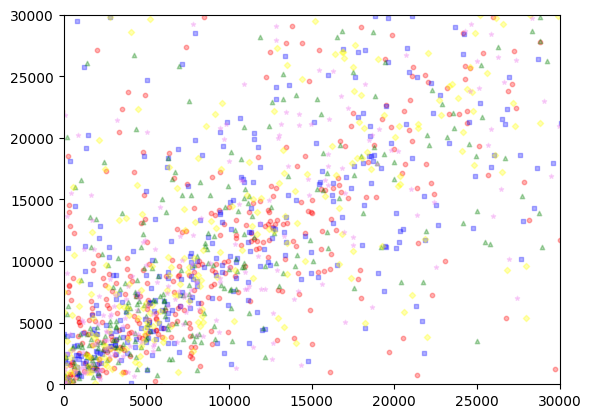

In [1459]:
plt.scatter(fin_pivot_comp['Прибыль_от_продаж_тыс_руб']['2021'], fin_pivot_comp['EBITDA']['2021'], c='red', marker='o', alpha=0.3, s=10)
plt.scatter(fin_pivot_comp['Прибыль_от_продаж_тыс_руб']['2022'], fin_pivot_comp['EBITDA']['2022'], c='blue', marker='s', alpha=0.3, s=10)
plt.scatter(fin_pivot_comp['Прибыль_от_продаж_тыс_руб']['2023'], fin_pivot_comp['EBITDA']['2023'], c='green', marker='^', alpha=0.3, s=10)
plt.scatter(fin_pivot_comp['Прибыль_от_продаж_тыс_руб']['2024'], fin_pivot_comp['EBITDA']['2024'], c='yellow', marker='D', alpha=0.3, s=10)
plt.scatter(fin_pivot_comp['Прибыль_от_продаж_тыс_руб']['2025'], fin_pivot_comp['EBITDA']['2025'], c='violet', marker='*', alpha=0.3, s=10)
plt.xlim(0, 30000)
plt.ylim(0, 30000)

По диаграмме рассеяния можно сделать вывод о том что больше всего показатели EBITDA и прибыль от продаж коррелируют в области малых
значений - малых компаний с небольшой прибыльностью, которые имеют незначительные показатели амортизации и не имеют кредитов либо имеют малые проценты
по ним, также не имеют других доходов и чистая прибыль почти что равна прибыли от продаж, но чем больше компания, чем больше она имеет прибыль или 
показатель EBITDA, тем больший вклад вносят кредиты, амортизация, прибыль складывается из разных показателей и не только от продаж, а значит тем с большей погрещностью можно использовать один показатель вместо другого

In [1462]:
for i in range(1, len(years)):
    fin_pivot_clear_pr[f'{years[i]}%growth'] = (fin_pivot_clear_pr[years[i]] - fin_pivot_clear_pr[years[0]])/fin_pivot_clear_pr[years[0]] * 100

In [1463]:
fin_pivot_clear_pr

Отчетный_год,ИНН,2021,2022,2023,2024,2025,2022%growth,2023%growth,2024%growth,2025%growth
0,105027747,47319.0,12160.0,19534.0,18001.0,11572.0,-74.302077,-58.718485,-61.958199,-75.544707
1,105043900,5403.0,7333.0,1513.0,0.0,-1748.0,35.720896,-71.997039,-100.000000,-132.352397
2,107027037,69869.0,648.0,27997.0,-302613.0,123421.0,-99.072550,-59.929296,-533.114829,76.646295
3,225004830,2200.0,13111.0,3633.0,2095.0,19364.0,495.954545,65.136364,-4.772727,780.181818
4,245021417,6103.0,3943.0,1260.0,982.0,420.0,-35.392430,-79.354416,-83.909553,-93.118139
...,...,...,...,...,...,...,...,...,...,...
1165,9718077983,-168304.0,-105042.0,-76270.0,-43278.0,-43137.0,-37.587936,-54.683192,-74.285816,-74.369593
1166,9721072953,17014.0,1979.0,2346.0,1674.0,27668.0,-88.368402,-86.211355,-90.161044,62.619020
1167,9723045458,11672.0,17853.0,19476.0,18916.0,3229.0,52.955792,66.860864,62.063057,-72.335504
1168,9725001287,1583.0,5368.0,13589.0,55.0,-22171.0,239.102969,758.433354,-96.525584,-1500.568541


In [ ]:
fin_pivot_clear_pr_c = fin_pivot_clear_pr.copy()
for i in range(1, len(years)):
    fin_pivot_clear_pr_c = fin_pivot_clear_pr_c[(fin_pivot_clear_pr[f'{years[i]}%growth'] < 1000) & (fin_pivot_clear_pr[f'{years[i]}%growth'] > -1000)]

In [1465]:
fin_pivot_clear_pr_c

Отчетный_год,ИНН,2021,2022,2023,2024,2025,2022%growth,2023%growth,2024%growth,2025%growth
0,105027747,47319.0,12160.0,19534.0,18001.0,11572.0,-74.302077,-58.718485,-61.958199,-75.544707
1,105043900,5403.0,7333.0,1513.0,0.0,-1748.0,35.720896,-71.997039,-100.000000,-132.352397
2,107027037,69869.0,648.0,27997.0,-302613.0,123421.0,-99.072550,-59.929296,-533.114829,76.646295
3,225004830,2200.0,13111.0,3633.0,2095.0,19364.0,495.954545,65.136364,-4.772727,780.181818
4,245021417,6103.0,3943.0,1260.0,982.0,420.0,-35.392430,-79.354416,-83.909553,-93.118139
...,...,...,...,...,...,...,...,...,...,...
1164,9718003519,-2784577.0,-256546.0,2022249.0,822940.0,123601.0,-90.786895,-172.623203,-129.553501,-104.438771
1165,9718077983,-168304.0,-105042.0,-76270.0,-43278.0,-43137.0,-37.587936,-54.683192,-74.285816,-74.369593
1166,9721072953,17014.0,1979.0,2346.0,1674.0,27668.0,-88.368402,-86.211355,-90.161044,62.619020
1167,9723045458,11672.0,17853.0,19476.0,18916.0,3229.0,52.955792,66.860864,62.063057,-72.335504


In [1466]:
fin_pivot_clear_pr_c[['2022%growth', '2023%growth', '2024%growth', '2025%growth']].describe()

Отчетный_год,2022%growth,2023%growth,2024%growth,2025%growth
count,859.000000,859.000000,859.000000,859.000000
mean,15.878315,12.594557,23.881665,17.534582
std,185.698758,210.987023,238.850685,243.983437
min,-775.790217,-841.389063,-920.521684,-948.537134
25%,-81.560872,-86.267864,-91.581355,-95.863728
50%,-23.505778,-35.405644,-32.175662,-55.043072
75%,55.327424,69.239509,89.246971,68.515870
max,918.806959,996.750000,994.799792,950.391797


In [ ]:
fin_pivot_clear_pr_c = fin_pivot_clear_pr.copy()
for i in range(1, len(years)):
    fin_pivot_clear_pr_c = fin_pivot_clear_pr_c[(fin_pivot_clear_pr[f'{years[i]}%growth'] < 250) & (fin_pivot_clear_pr[f'{years[i]}%growth'] > -250)]

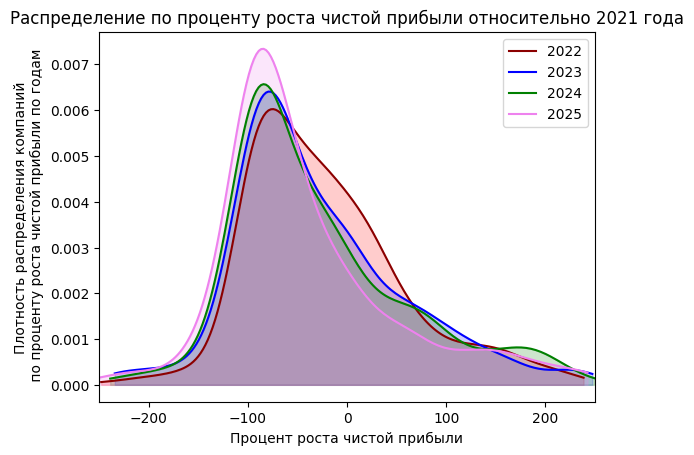

In [1473]:
#plt.hist(fin_pivot_clear_pr_c[['2022%growth']], bins=20, color='skyblue', density=True)

density1 = stats.gaussian_kde(fin_pivot_clear_pr_c['2022%growth'])
x_range1 = np.linspace(fin_pivot_clear_pr_c['2022%growth'].min(), fin_pivot_clear_pr_c['2022%growth'].max(), 200)
plt.plot(x_range1, density1(x_range1), color='darkred', label='2022')
plt.fill_between(x_range1, density1(x_range1), color='red', alpha=0.2)


density2 = stats.gaussian_kde(fin_pivot_clear_pr_c['2023%growth'])
x_range2 = np.linspace(fin_pivot_clear_pr_c['2023%growth'].min(), fin_pivot_clear_pr_c['2023%growth'].max(), 200)
plt.plot(x_range2, density2(x_range2), color='blue', label='2023')
plt.fill_between(x_range2, density2(x_range2), color='blue', alpha=0.2)

density3 = stats.gaussian_kde(fin_pivot_clear_pr_c['2024%growth'])
x_range3 = np.linspace(fin_pivot_clear_pr_c['2024%growth'].min(), fin_pivot_clear_pr_c['2024%growth'].max(), 200)
plt.plot(x_range3, density3(x_range3), color='green', label='2024')
plt.fill_between(x_range3, density3(x_range3), color='green', alpha=0.2)

density4 = stats.gaussian_kde(fin_pivot_clear_pr_c['2025%growth'])
x_range4 = np.linspace(fin_pivot_clear_pr_c['2025%growth'].min(), fin_pivot_clear_pr_c['2025%growth'].max(), 200)
plt.plot(x_range4, density4(x_range4), color='violet', label='2025')
plt.fill_between(x_range4, density4(x_range4), color='violet', alpha=0.2)

plt.xlim(-250, 250)
plt.title('Распределение по проценту роста чистой прибыли относительно 2021 года')
plt.xlabel('Процент роста чистой прибыли')
plt.ylabel('Плотность распределения компаний\n по проценту роста чистой прибыли по годам')
plt.legend()

In [ ]:
График плотности распределения компаний по проценту роста чистой прибыли по годам относительно 2021 года смешается влево, это значит что в среднем
рост чистой прибыли относительно 2021 года снижался все последние 4 года

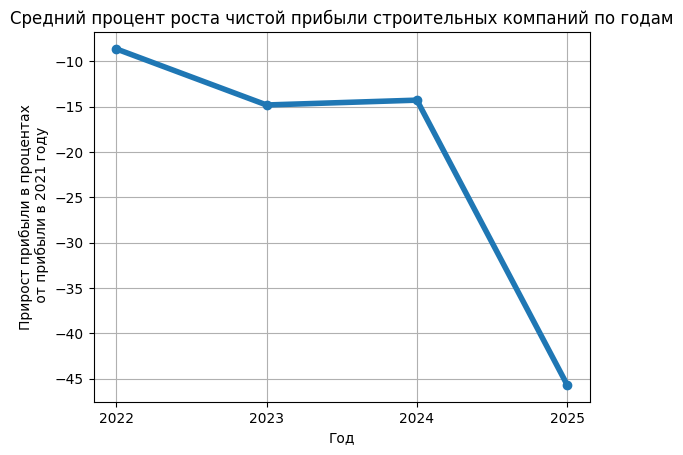

In [1480]:
mean = []
for i in range(1, len(years)):
    mean.append(fin_pivot_clear_pr[f'{years[i]}%growth'].median())
plt.plot(years[1:], mean, linewidth=4, marker='o')
plt.title('Средний процент роста чистой прибыли строительных компаний по годам')
plt.xlabel('Год')
plt.ylabel('Прирост прибыли в процентах\n от прибыли в 2021 году')
plt.grid()

In [ ]:
top500 = pd.merge(fin_info_t, r_a, on='ИНН', how='left')
top500

In [1482]:
top500 = top500[top500['Отчетный_год'] == 2025]

In [1483]:
top500 = top500.sort_values('Выручка_тыс_руб', ascending=False).head(500)
top500

,ИНН,Отчетный_год,Выручка_тыс_руб,Активы_тыс_руб,Прибыль_до_налогообложения_тыс_руб,Проценты_к_уплате_тыс_руб,Налог_на_прибыль_тыс_руб,Прибыль_от_продаж_тыс_руб,Основные_средства_на_конец_года_тыс_руб,Основные_средства_на_начало_года_тыс_руб,...,Наименование / ФИО,Категория,ОГРН,Код региона,Регион,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год,Год регистрации
17881,5401304044,2025,18261572.0,1155562.0,61454.0,733.0,-25306.0,210855.0,55505.0,66767.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОМ...",Среднее предприятие,1145476160774,54,Новосибирская область,г Новосибирск,2023-10-07,True,74.0,2023
35428,7702681515,2025,14902058.0,7406179.0,50987.0,0.0,-16012.0,174316.0,1460597.0,752388.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЭРБЕК""",Малое предприятие,1087746956571,77,г.Москва,г Москва,2016-01-08,False,47.0,2016
23337,5257145631,2025,12406715.0,11728365.0,3997806.0,102.0,-999451.0,3722958.0,3701930.0,7591909.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПЕЦ...",Малое предприятие,1145257003022,52,Нижегородская область,г Нижний Новгород,2016-01-08,False,25.0,2016
16026,4004021545,2025,11677648.0,42333.0,3999.0,665.0,-1033.0,-17354.0,NaN,NaN,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ОРГ-...",Среднее предприятие,1204000010532,40,Калужская область,г Кондрово,2021-10-01,False,1.0,2021
24613,7705989107,2025,10800142.0,5706824.0,124908.0,427896.0,-20899.0,465768.0,103974.0,122245.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПК-...",Малое предприятие,1127746470345,77,г.Москва,г Москва,2022-10-07,True,78.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30154,7806341601,2025,979329.0,1387142.0,2057.0,35566.0,-1020.0,36508.0,249254.0,363167.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Среднее предприятие,5067847163368,78,г.Санкт-Петербург,г Санкт-Петербург,2016-01-08,True,132.0,2016
14425,7728881702,2025,978525.0,440506.0,14093.0,20402.0,-11634.0,20997.0,6062.0,NaN,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МОНО...",Среднее предприятие,1147746691344,77,г.Москва,г Москва,2016-01-08,False,2.0,2016
11497,7722752281,2025,977763.0,338620.0,118665.0,NaN,-29781.0,112826.0,5576.0,1454.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""КОМП...",Малое предприятие,1117746589014,77,г.Москва,г Москва,2016-01-08,True,16.0,2016
591,1215048572,2025,977758.0,1923933.0,177093.0,5941.0,-46852.0,164281.0,69427.0,67853.0,...,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТР...",Малое предприятие,1021200771954,12,Республика Марий Эл,г Йошкар-Ола,2017-10-08,False,21.0,2017


In [1484]:
top500[~top500['Город или населенный пункт'].str.contains('г ')]

,ИНН,Отчетный_год,Выручка_тыс_руб,Активы_тыс_руб,Прибыль_до_налогообложения_тыс_руб,Проценты_к_уплате_тыс_руб,Налог_на_прибыль_тыс_руб,Прибыль_от_продаж_тыс_руб,Основные_средства_на_конец_года_тыс_руб,Основные_средства_на_начало_года_тыс_руб,...,Наименование / ФИО,Категория,ОГРН,Код региона,Регион,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год,Год регистрации
19493,7820338706,2025,8841618.0,3340728.0,40350.0,4922.0,-10158.0,4675.0,28874.0,45842.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""РЕСУ...",Среднее предприятие,1147847391097,78,г.Санкт-Петербург,п Шушары,2016-01-08,False,71.0,2016
9135,3923003260,2025,3779616.0,3246071.0,34441.0,13594.0,-8610.0,14603.0,NaN,NaN,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЗАПА...",Среднее предприятие,1023902270700,50,Московская область,Одинцово г,2023-10-07,False,24.0,2023
18553,4004016390,2025,3689967.0,5748438.0,8047.0,NaN,-2499.0,7622.0,9983.0,15902.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""РВД-3""",Малое предприятие,1124004000317,40,Калужская область,с Совхоз им. Ленина,2016-01-08,True,27.0,2016
18872,3706011835,2025,3403335.0,1130234.0,256822.0,0.0,-64971.0,242621.0,225161.0,209195.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""РЕЗЦ...",Среднее предприятие,1043700517992,37,Ивановская область,д Остапово,2016-01-08,False,248.0,2016
3818,4703142302,2025,3260590.0,4800475.0,2281308.0,4031.0,-589041.0,2541442.0,174567.0,1447198.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АРСЕ...",Малое предприятие,1144703003840,47,Ленинградская область,п Бугры,2016-01-08,False,19.0,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3660,7733895838,2025,1115159.0,1849667.0,NaN,NaN,-9283.0,NaN,32725.0,21026.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АРД ...",Малое предприятие,5147746142143,50,Московская область,Одинцово г,2016-01-08,False,10.0,2016
8837,275075025,2025,1107129.0,587066.0,81101.0,81.0,-23874.0,70166.0,142106.0,123723.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЕНЕР...",Среднее предприятие,1110280047437,2,Республика Башкортостан,с Михайловка,2016-01-08,True,30.0,2016
1548,2311194948,2025,1089345.0,439707.0,141824.0,0.0,-35436.0,132354.0,75315.0,92089.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТР...",Среднее предприятие,1152311011203,23,Краснодарский край,п Индустриальный,2016-01-08,True,129.0,2016
12725,6514009098,2025,1033238.0,1504320.0,516839.0,NaN,-146600.0,441670.0,144503.0,168392.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЛИДЕ...",Среднее предприятие,1126507000179,65,Сахалинская область,пгт Смирных,2016-01-08,False,60.0,2016


In [1485]:
top500['Город или населенный пункт'] = top500['Город или населенный пункт'].mask(top500['Город или населенный пункт'] == 'Одинцово г', 'г Одинцово')

In [1486]:
top500['Город или населенный пункт'] = top500['Город или населенный пункт'].mask(top500['Город или населенный пункт'] == 'Пушкино г', 'г Пушкино')

In [1487]:
top500['Город или населенный пункт'] = top500['Город или населенный пункт'].mask(top500['Город или населенный пункт'] == 'Наро-Фоминск г', 'г Наро-Фоминск')

In [1488]:
top500['Город или населенный пункт'] = top500['Город или населенный пункт'].mask(top500['Город или населенный пункт'] == 'ГОРОД НАЛЬЧИК', 'г Нальчик')

In [1489]:
top500['Город или населенный пункт'] = top500['Город или населенный пункт'].mask(top500['Город или населенный пункт'] == 'Клин г', 'г Клин')

In [1494]:
top500['Город или населенный пункт'] = top500['Город или населенный пункт'].str.split().str[1:]
top500['Город или населенный пункт'] = top500['Город или населенный пункт'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

In [1495]:
top500

,ИНН,Отчетный_год,Выручка_тыс_руб,Активы_тыс_руб,Прибыль_до_налогообложения_тыс_руб,Проценты_к_уплате_тыс_руб,Налог_на_прибыль_тыс_руб,Прибыль_от_продаж_тыс_руб,Основные_средства_на_конец_года_тыс_руб,Основные_средства_на_начало_года_тыс_руб,...,Наименование / ФИО,Категория,ОГРН,Код региона,Регион,Город или населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год,Год регистрации
17881,5401304044,2025,18261572.0,1155562.0,61454.0,733.0,-25306.0,210855.0,55505.0,66767.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОМ...",Среднее предприятие,1145476160774,54,Новосибирская область,Новосибирск,2023-10-07,True,74.0,2023
35428,7702681515,2025,14902058.0,7406179.0,50987.0,0.0,-16012.0,174316.0,1460597.0,752388.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЭРБЕК""",Малое предприятие,1087746956571,77,г.Москва,Москва,2016-01-08,False,47.0,2016
23337,5257145631,2025,12406715.0,11728365.0,3997806.0,102.0,-999451.0,3722958.0,3701930.0,7591909.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПЕЦ...",Малое предприятие,1145257003022,52,Нижегородская область,Нижний Новгород,2016-01-08,False,25.0,2016
16026,4004021545,2025,11677648.0,42333.0,3999.0,665.0,-1033.0,-17354.0,NaN,NaN,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ОРГ-...",Среднее предприятие,1204000010532,40,Калужская область,Кондрово,2021-10-01,False,1.0,2021
24613,7705989107,2025,10800142.0,5706824.0,124908.0,427896.0,-20899.0,465768.0,103974.0,122245.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СПК-...",Малое предприятие,1127746470345,77,г.Москва,Москва,2022-10-07,True,78.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30154,7806341601,2025,979329.0,1387142.0,2057.0,35566.0,-1020.0,36508.0,249254.0,363167.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРО...",Среднее предприятие,5067847163368,78,г.Санкт-Петербург,Санкт-Петербург,2016-01-08,True,132.0,2016
14425,7728881702,2025,978525.0,440506.0,14093.0,20402.0,-11634.0,20997.0,6062.0,NaN,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МОНО...",Среднее предприятие,1147746691344,77,г.Москва,Москва,2016-01-08,False,2.0,2016
11497,7722752281,2025,977763.0,338620.0,118665.0,NaN,-29781.0,112826.0,5576.0,1454.0,...,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""КОМП...",Малое предприятие,1117746589014,77,г.Москва,Москва,2016-01-08,True,16.0,2016
591,1215048572,2025,977758.0,1923933.0,177093.0,5941.0,-46852.0,164281.0,69427.0,67853.0,...,"АКЦИОНЕРНОЕ ОБЩЕСТВО ""СПЕЦИАЛИЗИРОВАННЫЙ ЗАСТР...",Малое предприятие,1021200771954,12,Республика Марий Эл,Йошкар-Ола,2017-10-08,False,21.0,2017


In [1496]:
city_table = pd.DataFrame(top500['Город или населенный пункт'].value_counts()).reset_index()

In [1497]:
cities = list(city_table['Город или населенный пункт'])

In [1308]:
import pandas as pd
import requests
import time

API_KEY = "09fa2eec-fba7-4710-abbd-a0eccfee063d"

cities = cities

def geocode_city(city):
    url = "https://geocode-maps.yandex.ru/v1"
    params = {
        "apikey": API_KEY,
        "geocode": city,
        "format": "json",
        "results": 1
    }
    try:
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        features = data["response"]["GeoObjectCollection"]["featureMember"]
        if features:
            pos = features[0]["GeoObject"]["Point"]["pos"]
            lon, lat = pos.split()
            return float(lat), float(lon)
    except Exception as e:
        print(f"Ошибка для {city}: {e}")
    return None, None

data = []
for idx, city in enumerate(cities, 1):
    print(f"{idx}/{len(cities)}: {city}")
    lat, lon = geocode_city(city)
    data.append({"city": city, "lat": lat, "lon": lon})
    time.sleep(0.5)

df = pd.DataFrame(data)
df.to_csv("city_coords.csv", index=False, encoding="utf-8")
print(df.head())

1/137: Москва
2/137: Санкт-Петербург
3/137: Екатеринбург
4/137: Казань
5/137: Уфа
6/137: Новосибирск
7/137: Краснодар
8/137: Красноярск
9/137: Пермь
10/137: Симферополь
11/137: Тюмень
12/137: Самара
13/137: Одинцово
14/137: Владивосток
15/137: Калуга
16/137: Челябинск
17/137: Южно-Сахалинск
18/137: Грозный
19/137: Химки
20/137: Ростов-на-Дону
21/137: Благовещенск
22/137: Воронеж
23/137: Нижний Новгород
24/137: Ялта
25/137: Волгоград
26/137: Саратов
27/137: Чебоксары
28/137: Ульяновск
29/137: Ярославль
30/137: Пушкино
31/137: Красногорск
32/137: Иркутск
33/137: Якутск
34/137: Липецк
35/137: Хабаровск
36/137: Балашиха
37/137: Сочи
38/137: Тверь
39/137: Белгород
40/137: Йошкар-Ола
41/137: Вологда
42/137: Шушары
43/137: Мытищи
44/137: Сургут
45/137: Домодедово
46/137: Люберцы
47/137: Калининград
48/137: Жуковский
49/137: Барнаул
50/137: Ижевск
51/137: Набережные Челны
52/137: Пятигорск
53/137: Чита
54/137: Магнитогорск
55/137: Орск
56/137: Разумное
57/137: Тула
58/137: Губкинский
59/137: О

In [1498]:
df

,city,lat,lon
0,Москва,55.755864,37.617698
1,Санкт-Петербург,59.938784,30.314997
2,Екатеринбург,56.837435,60.597636
3,Казань,55.796127,49.106414
4,Уфа,54.735152,55.958736
...,...,...,...
132,Когалым,62.264069,74.482761
133,Смирных,49.742866,142.831358
134,Смоленск,54.778263,32.051054
135,Семилуки,51.694630,39.020211


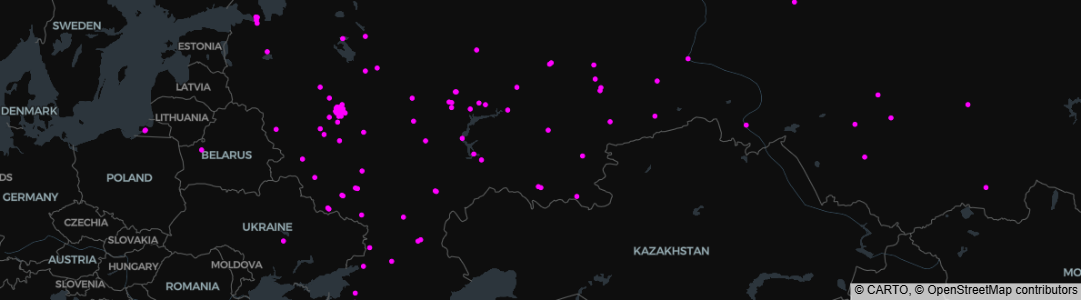

In [1499]:
import plotly.express as px

fig = px.scatter_map(df, lat="lat", lon="lon", hover_name="city", #hover_data=["State", "Population"],
                        color_discrete_sequence=["fuchsia"], zoom=3, height=300)
fig.update_layout(map_style="dark")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

Компании из топ-500 по выручке расположены в основном в европейской части страны, где сосредоточено основное население, предприятия и производтва, крупные города

**Основные выводы:**


1. Большинство компаний и работников сосредоточено в самых крупных городах страны, большей частью предприятия являются малыми,    
в большей части компаний количество сотрудников составляет до 50 человек, территориально компании по большей части расположены в европейской части
страны и крупных городах, где соредоточено основное население, предприятия и производста
3. Количество регистрируемых новых компаний увеличивалось с 2020 по 2022 годы, снижалось с 2022 по 2025 годы, что может быть связано с ковидом (так как предположительно, спрос на жилые дома мог вырасти, ковид показал людям нестабильность современного мира, что могло привести к желанию приобрести капитал в виде недвижимости, также открылись возможности в виде удаленной работы и многие стали готовы переехать
за город - создался большой спрос), далее после 2022 года произошло падение регистрации новых компаний, экономика перестала расти, начали подниматься ставки по кредитам, что могло сильно повлиять на темпы появления новых компаний.
4. Проанализированы 2 показателя - EBITDA и прибыль от продаж на разных выборках.
5. Анализ показателя прибыли от продаж показал, что имееются сильные выбросы - компании с большими убытками или большой прибылью, медианное значение прибыли от продаж снижается год от года, но среднее растет - в последние годы экономическая ситуация отражается на строительном бизнесе плохо, снижается прибыльность бизнеса, но тем не менее гиганты продолжают расти и увеличивать прибыль. Средняя прибыль от продаж росла с 2021 по 2022 годы, а затем, предположительно, в связи с началом СВО, ухода иностранных компаний, дестабилизации экономической обстановки, показатели прибыльности начали стремительно падать и особенно заметна разница между 2024 и 2025 годом, также на снижение может влиять повышение налогов и процентов по кредитам в последние годы. Небольшой рост с 2022 по 2023 год может быть связан с тем, что строительная отрасль очень инертная - так как срок реализации проектов может быть долгим, наступление кризиса для этой отрасли часто отстает на 1-2 года
По самым крупным городам по количеству компаний наблюдается также снижение прибыльности, если до 2024 года в некоторых городах отмечался рост, то после 2024 практически во всех городах показатель упал. Также можно заметить, что доля тех компаний, которые работают в убыток растет с каждым годом, и сильнее всего с 2024 по 2025 годы
6. Анализ показателя EBITDA показал что данные по среднему отличаются от прибыли от продаж, что скорее всего вызвано нерепрезентативностью выборки, в остальном, характер изменений показателя по годам такой же как и прибыли от продаж, но в случае с изменениям показателя по городам, сложно сформулировать вывод, значения сильно отличаются для разных крупных городов
7. В среднем рост чистой прибыли относительно 2021 года снижался все последующие годы

Таким образом, так как все основные показатели снижаются последние годы - количество новых компаний уменьшается, прибыльность в среднем снижается, убыточность увеличивается, нельзя сказать, что строительная отрасль является перспективной